In [1]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/FilippoTeodorani/Ethics_for_AI/refs/heads/main/dataset.csv", sep = ",")

# Data preparation

In [2]:
df['civil_status_num'] = df['civil_status'].map({'cohabitants': 0, 'married': 1})
df = df.drop('civil_status', axis = 1)

df['ability_to_educate_num'] = df['ability_to_educate'].map({'no': 0, 'yes': 1})
df = df.drop('ability_to_educate', axis = 1)

df['criminal_record_num'] = df['criminal_record'].map({'no': 0, 'yes': 1})
df = df.drop('criminal_record', axis = 1)

df

,age_parent_1,age_parent_2,mean_age_parents,years_of_relation,biological_children,education_parent_1,education_parent_2,weekly_work_hours_parent_1,weekly_work_hours_parent_2,years_of_work_parent_1,...,number_of_rooms,space_for_new_child,salary_parent_1,salary_parent_2,total_couple_salary,approved,score,civil_status_num,ability_to_educate_num,criminal_record_num
0,49,54,51.5,3,0,degree,degree,0,20,0,...,12,room_present,0,13210,13210,0.0,10.5074,1,0,0
1,42,42,42.0,19,0,high_school,degree,30,40,22,...,8,room_present,19224,25075,44299,1.0,13.6017,1,1,0
2,39,37,38.0,11,1,high_school,degree,0,0,0,...,7,room_present,0,0,0,0.0,2.1534,1,1,0
3,44,42,43.0,6,0,degree,degree,45,0,19,...,8,room_present,37238,0,37238,0.0,8.6500,1,1,0
4,44,49,46.5,16,0,degree,degree,50,20,19,...,6,room_present,43536,11213,54749,1.0,13.6827,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,40,37,38.5,13,0,degree,medium_school,20,35,15,...,7,room_present,15120,18161,33281,0.0,9.5306,0,1,0
9996,39,41,40.0,5,0,high_school,degree,40,40,19,...,8,room_present,31315,21734,53049,0.0,10.5012,1,1,0
9997,35,38,36.5,12,0,degree,degree,0,40,0,...,10,room_present,0,27706,27706,1.0,12.0171,1,1,0
9998,50,51,50.5,23,0,high_school,degree,45,20,30,...,4,no_space,32789,12317,45106,0.0,-10.0000,1,1,0


In [3]:
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder(categories=[['medium_school', 'high_school', 'degree']])
df['education_parent_1_ord'] = enc.fit_transform(df[['education_parent_1']])
df = df.drop('education_parent_1', axis=1)

df['education_parent_2_ord'] = enc.fit_transform(df[['education_parent_2']])
df = df.drop('education_parent_2', axis=1)

'''enc = OrdinalEncoder(categories=[['no_space', 'space_present', 'room_present']])
df['space_for_new_child_ord'] = enc.fit_transform(df[['space_for_new_child']])'''
df = df.drop('space_for_new_child', axis=1)

In [4]:
dummies = pd.get_dummies(df['type_of_contract_parent_1'], prefix='contract_parent_1', dtype=int)
df = pd.concat([df, dummies], axis=1)

dummies = pd.get_dummies(df['type_of_contract_parent_2'], prefix='contract_parent_2', dtype=int)
df = pd.concat([df, dummies], axis=1)

dummies = pd.get_dummies(df['house_contract'], prefix='house_contract', dtype=int)
df = pd.concat([df, dummies], axis=1)

df = df.drop('type_of_contract_parent_1', axis=1)
df = df.drop('type_of_contract_parent_2', axis=1)
df = df.drop('house_contract', axis=1)
df

,age_parent_1,age_parent_2,mean_age_parents,years_of_relation,biological_children,weekly_work_hours_parent_1,weekly_work_hours_parent_2,years_of_work_parent_1,years_of_work_parent_2,preferences,...,contract_parent_1_permanent,contract_parent_1_self_employed,contract_parent_1_temporary,contract_parent_2_no_contract,contract_parent_2_permanent,contract_parent_2_self_employed,contract_parent_2_temporary,house_contract_property,house_contract_rent,house_contract_usufruct
0,49,54,51.5,3,0,0,20,0,29,0,...,0,0,0,0,0,1,0,1,0,0
1,42,42,42.0,19,0,30,40,22,17,1,...,1,0,0,0,1,0,0,1,0,0
2,39,37,38.0,11,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1
3,44,42,43.0,6,0,45,0,19,0,1,...,1,0,0,1,0,0,0,0,1,0
4,44,49,46.5,16,0,50,20,19,24,1,...,0,0,1,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,40,37,38.5,13,0,20,35,15,21,1,...,0,0,1,0,0,1,0,1,0,0
9996,39,41,40.0,5,0,40,40,19,16,1,...,1,0,0,0,0,1,0,1,0,0
9997,35,38,36.5,12,0,0,40,0,13,0,...,0,0,0,0,1,0,0,1,0,0
9998,50,51,50.5,23,0,45,20,30,26,1,...,1,0,0,0,1,0,0,1,0,0


In [5]:
# 1. Import delle librerie
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y = df['approved']
X = df.drop(['approved', 'score', 'weekly_work_hours_parent_1', 'weekly_work_hours_parent_2', 'salary_parent_1', 'salary_parent_2', 'ability_to_educate_num'], axis=1)
# 3. Suddivisione in train e test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("clf", RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        class_weight={0.0: 0.671, 1.0: 1.957}
    ))
])

# 5. Addestramento del modello
pipeline.fit(X_train, y_train)

# 6. Valutazione sul test set
y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.938

Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.98      0.96      1489
         1.0       0.92      0.83      0.87       511

    accuracy                           0.94      2000
   macro avg       0.93      0.90      0.92      2000
weighted avg       0.94      0.94      0.94      2000


Confusion Matrix:
 [[1454   35]
 [  89  422]]


# XAI

In [6]:
import numpy as np
import shap

# Initialize explainer on the RandomForest inside the pipeline
explainer = shap.TreeExplainer(pipeline.named_steps['clf'])

# Get SHAP values for X_test (the raw features)
shap_values = explainer.shap_values(X_test)

shap_values_obj = explainer(X_test)

shap_values_array = shap_values_obj.values  # shape (1000, 33, 2)

# Transpose to (2, 1000, 33)
shap_values = np.transpose(shap_values_array, (2, 0, 1))

shap.initjs()

### Example of SHAP usage for one observation

Predizione classe: 1.0, probabilità: [0.14 0.86]


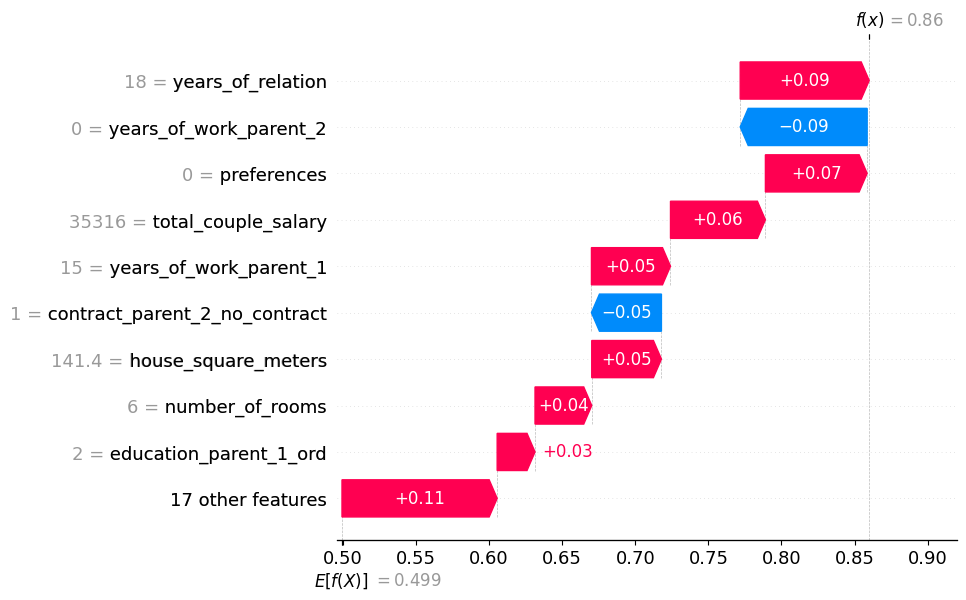

In [7]:
# x_obs deve essere di forma (1, numero_feature)
x_obs = X_test.iloc[[0]]  # esempio: prima riga

# Predizione della classe
pred_class = pipeline.predict(x_obs)[0]

# Probabilità predetta
pred_proba = pipeline.predict_proba(x_obs)[0]
print(f"Predizione classe: {pred_class}, probabilità: {pred_proba}")

import shap

# SHAP values per la singola osservazione
shap_values_single = explainer(x_obs)

# Seleziona la classe predetta (per classificazione binaria)
class_idx = int(pred_class)  # 0 o 1

# Creiamo un oggetto Explanation corretto per il waterfall plot
shap_exp_single = shap.Explanation(
    values=shap_values_single.values[0][:, class_idx] if shap_values_single.values.ndim == 3 else shap_values_single.values[0],
    base_values=shap_values_single.base_values[0] if shap_values_single.base_values.ndim == 1 else shap_values_single.base_values[0][class_idx],
    data=x_obs.iloc[0]
)

shap.initjs()

# Waterfall plot della singola osservazione
shap.plots.waterfall(shap_exp_single)




### General variance importance

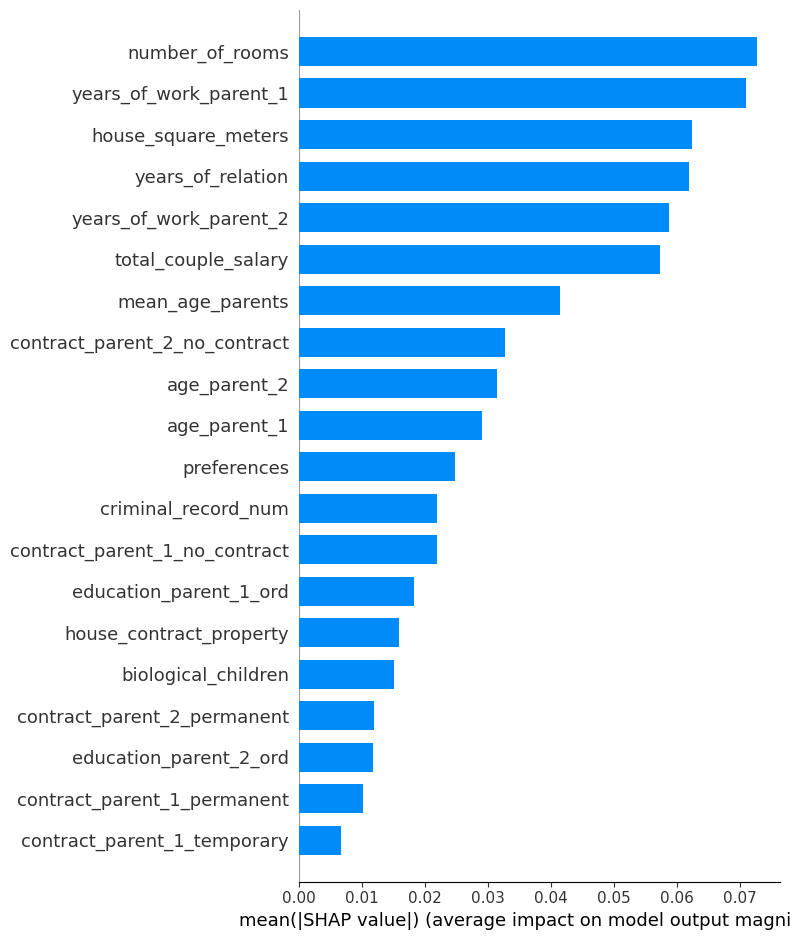

In [8]:
shap.summary_plot(shap_values[1], X_test, plot_type="bar")


# LLM

In [16]:
import os
from huggingface_hub import InferenceClient
from getpass import getpass

# ATTENZIONE: IL TOKEN HF SI TROVA NEI COLAB SECRETS (DA COPIARE E INCOLLARE)

LLM_API_KEY = os.environ.get("LLM_API_KEY") or getpass("Incolla qui il tuo CEREBRAS_API_KEY (input nascosto): ")
os.environ["LLM_API_KEY"] = LLM_API_KEY

client = InferenceClient(
    provider="cerebras",
    api_key=LLM_API_KEY,
)

Example of usage of our LLM on SHAP values

In [17]:
import warnings
warnings.filterwarnings('ignore')

# Seleziona l'indice della coppia da analizzare, es. idx = 0
idx = 0

# Estrai i valori SHAP della classe "approved" = 1 per la coppia idx
shap_vals_sample = shap_values[1][idx]  # array di shape (33,)

# Estrai i nomi delle feature
feature_names = X_test.columns.tolist()

# Estrai i valori delle feature per quella coppia
feature_values = X_test.iloc[idx].to_dict()

explanation_input = (
    "Explain the SHAP values a example in a classification model predicting adoption approval.\n"
    "Feature contributions:\n"
)

for name, val, shap_val in zip(feature_names, feature_values.values(), shap_vals_sample):
    sign = "positive" if shap_val > 0 else "negative"
    explanation_input += f"- {name}: value={val}, contribution={shap_val:.3f} ({sign} impact)\n"

explanation_input += (
    "\nSummarize the most influential features impact for that couple.\n"
    "Do NOT include any reasoning steps or intermediate explanations. ONLY provide a final concise summary "
    "in no more than 10 lines."
)
# Ora manda questo testo nel messaggio "content" al modello LLM
completion = client.chat.completions.create(
    model="meta-llama/Llama-3.1-8B-Instruct",
    messages=[
        {
            "role": "user",
            "content": explanation_input
        }
    ],
)
print(completion.choices[0].message.content)

The most influential features for this couple are:

- years_of_work_parent_1: value=15.0, contribution=0.054, positive impact
- house_contract_property: value=1.0, contribution=0.024, positive impact
- years_of_relation: value=18.0, contribution=0.088, positive impact
- total_couple_salary: value=35316.0, contribution=0.065, positive impact
- preferences: value=0.0, contribution=0.070, positive impact
- education_parent_2_ord: value=2.0, contribution=0.020, positive impact
- contract_parent_1_temporary: value=0.0, contribution=0.009, positive impact
- contract_parent_1_permanent: value=1.0, contribution=0.010, positive impact
- education_parent_1_ord: value=2.0, contribution=0.026, positive impact
- house_contract_rent: value=0.0, contribution=0.006, positive impact


# Platform

In [18]:
import joblib, pickle
import pandas as pd
import numpy as np
import shap
import gradio as gr
import matplotlib.pyplot as plt
from pathlib import Path

In [19]:
joblib.dump(pipeline, "/content/model.joblib")

['/content/model.joblib']

In [21]:
import os
import joblib
import pandas as pd
import numpy as np
import gradio as gr
import traceback
from pathlib import Path
from huggingface_hub import InferenceClient

# ---------------- CONFIG ----------------
MODEL_PATH = "/content/model.joblib"
GRADIO_SHARE = True
TOP_K_SUGGESTIONS = 5

# LLM settings
from getpass import getpass
import os

LLM_PROVIDER = "cerebras"
LLM_API_KEY = os.environ.get("LLM_API_KEY")
LLM_MODEL = "meta-llama/Llama-3.1-8B-Instruct"
# ----------------------------------------

# ---------------- Feature descriptions ----------------
FEATURE_DESCRIPTIONS = {
    "age_parent_1": "Enter the age of parent 1 (if M/F couple insert the age of the male)",
    "age_parent_2": "Enter the age of parent 2 (if M/F couple insert the age of the female)",
    "years_of_relation": "Enter the years of relation",
    "biological_children": "Enter the number of biological children",
    "years_of_work_parent_1": "Enter the number of years of work of parent 1",
    "years_of_work_parent_2": "Enter the number of years of work of parent 2",
    "preferences": "Enter 1 if you have any preferences of age and provenience of the child, 0 otherwise",
    "house_square_meters": "Enter the squared meters of the house",
    "number_of_rooms": "Enter the number of rooms of the house",
    "total_couple_salary": "Enter the total gross annual salary of the couple",
    "civil_status_num": "Enter 1 if you are married, 0 otherwise",
    "education_parent_1_ord": "Enter 0 if parent 1 has a middle school diploma or lower, 1 if they have a high school diploma, 2 if they have a university degree.",
    "education_parent_2_ord": "Enter 0 if parent 2 has a middle school diploma or lower, 1 if they have a high school diploma, 2 if they have a university degree.",
    "contract_parent_1_no_contract": "Enter 1 if parent 1 does not have any employment contract currently, 0 otherwise.",
    "contract_parent_1_permanent": "Enter 1 if parent 1 has a permanent employment contract, 0 otherwise",
    "contract_parent_1_self_employed": "Enter 1 if Parent 1 is self-employed, 0 otherwise.",
    "contract_parent_1_temporary": "Enter 1 if parent 1 has a fixed-term employment contract, 0 otherwise",
    "contract_parent_2_no_contract": "Enter 1 if parent 2 does not have any employment contract currently, 0 otherwise.",
    "contract_parent_2_permanent": "Enter 1 if parent 2 has a permanent employment contract, 0 otherwise",
    "contract_parent_2_self_employed": "Enter 1 if Pparent 2 is self-employed, 0 otherwise.",
    "contract_parent_2_temporary": "Enter 1 if parent 2 has a fixed-term employment contract, 0 otherwise",
    "house_contract_property": "Enter 1 if the house is owned by one or both members of the couple, 0 otherwise.",
    "house_contract_rent": "Insert 1 if the house is for rent, 0 otherwise.",
    "house_contract_usufruct": "Enter 1 if the house is in usufruct, 0 otherwise",
    "criminal_record_num": "Enter 1 if at least one of the two members of the couple has a criminal record, 0 otherwise.",
    "mean_age_parents": "You can enter whatever you want here, the mean age will be automatically calculated"
}

# Carica modello ML (pipeline)
if Path(MODEL_PATH).exists():
    model = joblib.load(MODEL_PATH)
    print(f"ML model uploaded by {MODEL_PATH}")
else:
    if 'pipeline' in globals():
        model = globals()['pipeline']
        print("Used 'pipeline' present in the session as a model.")
    else:
        raise FileNotFoundError("I can't find your ML model. Save it in MODEL_PATH or leave 'pipeline' in memory.")

# Ottieni feature names da X
if 'X' in globals() and isinstance(globals()['X'], pd.DataFrame):
    X_df = globals()['X']
    FEATURE_NAMES = list(X_df.columns)
    if not FEATURE_NAMES:
        raise RuntimeError("FEATURE_NAMES empty: run the cell that defines X or manually enter the list.")

# Popola FEATURE_TYPES e FEATURE_RANGES da X
FEATURE_TYPES = {}
FEATURE_RANGES = {}
if 'X_df' not in globals() and 'X' in globals():
    X_df = globals()['X']
if 'X_df' in globals():
    for feat in FEATURE_NAMES:
        ser = X_df[feat]
        if pd.api.types.is_numeric_dtype(ser):
            FEATURE_TYPES[feat] = "numeric"
            try:
                FEATURE_RANGES[feat] = (float(ser.min()), float(ser.max()))
            except Exception:
                FEATURE_RANGES[feat] = (0.0, 1.0)
        else:
            uniques = ser.dropna().unique()
            str_u = [str(x) for x in uniques]
            if len(str_u) <= 50:
                FEATURE_TYPES[feat] = str_u
            else:
                FEATURE_TYPES[feat] = "text"

# ---------------- LLM client helper (conversational) ----------------
llm_client = None
if LLM_API_KEY:
    try:
        llm_client = InferenceClient(provider=LLM_PROVIDER, api_key=LLM_API_KEY)
        print("LLM client created (InferenceClient, provider=nebius).")
    except Exception:
        traceback.print_exc()
        llm_client = None
else:
    print("No LLM API key found. If you want to use the LLM, set NEBIUS_API_KEY as an environment variable..")

def call_llm_interpretation_conversational(suggestions, prob, top_n=5, model_name=LLM_MODEL):
    """
    Use the conversational endpoint (chat_completion) to turn suggestions into understandable natural text.
    """
    if llm_client is None:
        return "LLM not configured: set CEREBRAS_API_KEY and try again."

    system_msg = {
        "role": "system",
        "content": (
            "You are an assistant that translates technical suggestions on features of a model. "
            "Give advice to people who would like to adopt a child based on results."
        )
    }

    user_lines = []
    user_lines.append(f"Current probability of success: {prob*100:.1f}%.")
    user_lines.append("Below are the automatically calculated suggestions (feature, current value -> suggested value, estimated new prob, delta):")
    for s in suggestions[:top_n]:
        user_lines.append(f"- {s['feature']}: {s['current']} -> {s['suggested']} (nuova prob {s['new_prob']*100:.2f}%, Δ {s['delta_prob']*100:.2f}%)")
    user_lines.append("")
    user_lines.append(
        "For each suggestion, summarize in 1-2 sentences what the user should do concretely and why this could increase the likelihood."
        "If the suggestion is not feasible, provide practical alternatives. Finally, provide 3 prioritized recommendations ordered by expected impact."
        "Focus only on negative values of shap to give advice and AVOID TO PRINT THE THINKING STEPS. Do not include it."
    )
    user_msg = {"role": "user", "content": "\n".join(user_lines)}

    messages = [system_msg, user_msg]

    params = {
        "max_tokens": 2048,
        "temperature": 0.0,
    }

    try:
        resp = llm_client.chat_completion(messages=messages, model=model_name, **params)

        if isinstance(resp, str):
            return resp.strip()
        try:
            if hasattr(resp, "choices"):
                ch = resp.choices
                if len(ch) > 0:
                    message = ch[0].get("message") if isinstance(ch[0], dict) else ch[0]
                    if isinstance(message, dict) and "content" in message:
                        return message["content"].strip()
                    return str(ch[0]).strip()
            if hasattr(resp, "generations"):
                gen = resp.generations
                if len(gen) > 0:
                    g0 = gen[0]
                    if isinstance(g0, dict):
                        if "text" in g0:
                            return g0["text"].strip()
                        if "message" in g0 and isinstance(g0["message"], dict) and "content" in g0["message"]:
                            return g0["message"]["content"].strip()

                    return str(g0).strip()
            if isinstance(resp, dict):
                if "choices" in resp and isinstance(resp["choices"], list) and resp["choices"]:
                    c0 = resp["choices"][0]
                    if isinstance(c0, dict) and "message" in c0 and "content" in c0["message"]:
                        return c0["message"]["content"].strip()
                    if isinstance(c0, dict) and "text" in c0:
                        return c0["text"].strip()
                if "generations" in resp and isinstance(resp["generations"], list) and resp["generations"]:
                    g0 = resp["generations"][0]
                    if isinstance(g0, dict) and "text" in g0:
                        return g0["text"].strip()
                return str(resp)
            return str(resp)
        except Exception:
            return str(resp)
    except Exception as e:
        print("Error during chat_completion() call:")
        traceback.print_exc()
        return f"Error in LLM generation (chat_completion): {str(e)}"

# ---------------- ML helper (preprocess/predict/suggestions) ----------------
def preprocess_input(raw_dict):
    df = pd.DataFrame([raw_dict])[FEATURE_NAMES]

    # conversione tipi
    for feat in FEATURE_NAMES:
        ftype = FEATURE_TYPES.get(feat, "numeric")
        if ftype == "numeric":
            df[feat] = pd.to_numeric(df[feat], errors='coerce')
        elif isinstance(ftype, list):
            df[feat] = df[feat].astype(str)
        else:
            df[feat] = df[feat].astype(str)

    # calcolo automatico età media genitori
    if "age_parent_1" in df.columns and "age_parent_2" in df.columns:
        df["mean_age_parents"] = (df["age_parent_1"] + df["age_parent_2"]) / 2

    return df

def predict_proba_df(X_df):
    try:
        p = model.predict_proba(X_df)[:,1]
        return np.array(p)
    except Exception:
        return model.predict_proba(X_df.values)[:,1]
8

# ---------------- Gradio UI ----------------

# === modifica UI con descrizioni e default=0 ===
inputs = []
for feat in FEATURE_NAMES:

    ftype = FEATURE_TYPES.get(feat, "numeric")
    desc = FEATURE_DESCRIPTIONS.get(feat, feat)
    if isinstance(ftype, list):
        inputs.append(gr.Dropdown(choices=[str(x) for x in ftype], label=feat, info=desc))
    elif ftype == "numeric":
        inputs.append(gr.Number(value=0, label=feat, info=desc))
    else:
        inputs.append(gr.Textbox(label=feat, info=desc))

def predict_interface(*args, use_llm: bool = True):
    try:
        # 1. Build raw input dict
        raw = {FEATURE_NAMES[i]: args[i] for i in range(len(FEATURE_NAMES))}
        df = preprocess_input(raw)
        # 2. Predict probability
        prob = float(predict_proba_df(df)[0])
        prob_txt = f"Probability of success (class=1): {prob*100:.2f}%"

        shap_values_single = explainer(df)

        shap_exp_single = shap.Explanation(
            values=shap_values_single.values[0][:, 1] if shap_values_single.values.ndim == 3 else shap_values_single.values[0],
            base_values=shap_values_single.base_values[0] if shap_values_single.base_values.ndim == 1 else shap_values_single.base_values[0][1],
            data=df.iloc[0]
        )

        # 3. Compute SHAP values for this single sample
        shap_vals = shap_exp_single.values
        feature_names = FEATURE_NAMES
        feature_values = df.iloc[0].to_dict()

        # 4. Build explanation input string
        explanation_input = (
            "Explain the SHAP values for a classification model predicting adoption approval.\n"
            f"Predicted probability of approval: {prob*100:.2f}%.\n\n"
            "Feature contributions:\n"
        )
        for name, val, shap_val in zip(feature_names, feature_values.values(), shap_vals):
            '''if isinstance(shap_val, (np.ndarray, list)):
                shap_val_scalar = float(np.sum(shap_val))  # sum contributions
            else:
                shap_val_scalar = float(shap_val)
                '''
            sign = "positive" if shap_val > 0 else "negative"
            explanation_input += f"- {name}: value={val}, contribution={shap_val:.6f} ({sign} impact)\n"

        explanation_input += (
            "\nSummarize the most influential features for this couple, "
            "providing a concise interpretation of why they matter."
        )

        # 5. If LLM is enabled, send SHAP explanation to it
        if use_llm:
            messages = [
                {"role": "system", "content": "You are an assistant that explains SHAP values in clear, language, but give real life advice."},
                {"role": "user", "content": explanation_input}
            ]
            try:
                resp = llm_client.chat_completion(messages=messages, model=LLM_MODEL, max_tokens=1024, temperature=0.0)
                if isinstance(resp, dict) and "choices" in resp:
                    llm_text = resp["choices"][0]["message"]["content"].strip()
                else:
                    llm_text = str(resp)
            except Exception as e:
                traceback.print_exc()
                llm_text = f"Error calling LLM: {e}"
        else:
            llm_text = "LLM not used (toggle off)."

        return prob_txt, explanation_input, llm_text

    except Exception as e:
        traceback.print_exc()
        return "Error", str(e), ""


# outputs: checkbox per attivare/disattivare LLM
llm_toggle = gr.Checkbox(label="Use LLM to interpret suggestions", value=True)
outputs = [
    gr.Textbox(label="Probability"),
    gr.Textbox(label="Raw suggestions"),
    gr.Textbox(label="Suggestions")
]

iface = gr.Interface(fn=predict_interface, inputs=inputs + [llm_toggle], outputs=outputs,
                     title="AIdoption",
                     description="Enter the values and get predictions, raw suggestions, and interpreted version.")
print("Launch interface Gradio...")
iface.launch(share=GRADIO_SHARE)

ML model uploaded by /content/model.joblib
LLM client created (InferenceClient, provider=nebius).
Launch interface Gradio...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://10d3d84ced3547efba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# USER EXPERIENCE DESIGN (PROJECT WORK)

## 1 - Reliability Diagram, Calibration Model and Brier Score

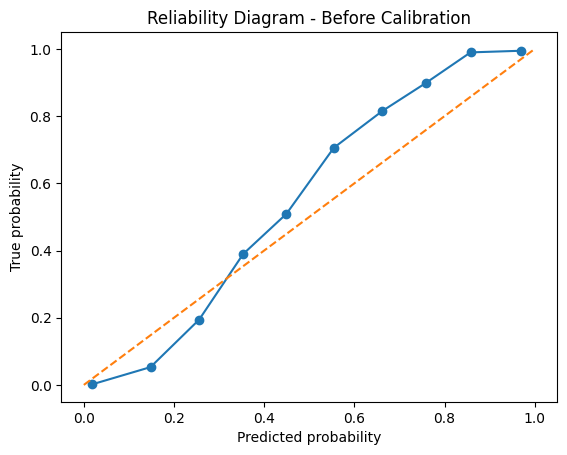

Brier Score: 0.0471802


In [22]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

probs_test = pipeline.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(y_test, probs_test, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Reliability Diagram - Before Calibration")
plt.show()

print("Brier Score:", brier_score_loss(y_test, probs_test))

In [23]:
from sklearn.calibration import CalibratedClassifierCV

rf_calibrated = CalibratedClassifierCV(
    pipeline,
    method='isotonic',   # oppure 'sigmoid'
    cv=5
)

rf_calibrated.fit(X_train, y_train)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('clf',
                                                  RandomForestClassifier(class_weight={0.0: 0.671,
                                                                                       1.0: 1.957},
                                                                         random_state=42))]),
                       method='isotonic')

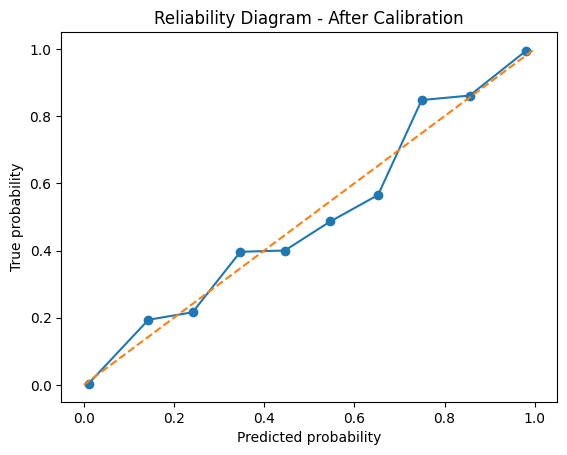

Brier Score (calibrated): 0.04472439158934124


In [24]:
probs_test_cal = rf_calibrated.predict_proba(X_test)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_test, probs_test_cal, n_bins=10)

plt.figure()
plt.plot(prob_pred_cal, prob_true_cal, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Reliability Diagram - After Calibration")
plt.show()

print("Brier Score (calibrated):", brier_score_loss(y_test, probs_test_cal))

## 2 - Confidence Interval, Reliability Label and OOD Distance

In [25]:
import numpy as np

def predict_with_uncertainty(model, X_train, y_train, x_input, n_bootstrap=100):

    preds = []

    n = len(X_train)

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, n, replace=True)
        X_sample = X_train.iloc[idx]
        y_sample = y_train.iloc[idx]

        model_boot = RandomForestClassifier(
            n_estimators=200,
            random_state=None
        )
        model_boot.fit(X_sample, y_sample)

        prob = model_boot.predict_proba(x_input.reshape(1, -1))[0, 1]
        preds.append(prob)

    mean_prob = np.mean(preds)
    lower = np.percentile(preds, 2.5)
    upper = np.percentile(preds, 97.5)

    return mean_prob, lower, upper

In [26]:
import warnings
warnings.filterwarnings('ignore')

x_new = X_test.iloc[0:1].values

calibrated_prob = rf_calibrated.predict_proba(x_new)[0, 1]

mean_prob, lower_ci, upper_ci = predict_with_uncertainty(
    pipeline,
    X_train,
    y_train,
    x_new
)

In [27]:
print(x_new)
print(f"Probabilità calibrata: {mean_prob:.4f}")
print(f"Intervallo di confidenza 95%: {lower_ci:.4f} - {upper_ci:.4f}")

[[4.0000e+01 4.1000e+01 4.0500e+01 1.8000e+01 0.0000e+00 1.5000e+01
  0.0000e+00 0.0000e+00 1.4140e+02 6.0000e+00 3.5316e+04 1.0000e+00
  0.0000e+00 2.0000e+00 2.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00
  0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 1.0000e+00
  0.0000e+00 0.0000e+00]]
Probabilità calibrata: 0.7447
Intervallo di confidenza 95%: 0.6269 - 0.8402


In [28]:
def reliability_label(prob, lower, upper):

    width = upper - lower

    if width < 0.10:
        return "Alta affidabilità"
    elif width < 0.20:
        return "Affidabilità media"
    else:
        return "Bassa affidabilità"

reliability_label(mean_prob, lower_ci, upper_ci)

'Bassa affidabilità'

In [29]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_train)

def compute_ood_score(x_new):
    dist, _ = nn.kneighbors(x_new.reshape(1, -1))
    return dist.mean()

train_distances, _ = nn.kneighbors(X_train)
threshold = np.percentile(train_distances.mean(axis=1), 95)

ood_score = compute_ood_score(x_new)

if ood_score > threshold:
    print("ATTENZIONE: profilo fuori distribuzione: il modello potrebbe essere meno affidabile.")

## 3 - Counterfactual Exploration

In [30]:
df.describe()

,age_parent_1,age_parent_2,mean_age_parents,years_of_relation,biological_children,weekly_work_hours_parent_1,weekly_work_hours_parent_2,years_of_work_parent_1,years_of_work_parent_2,preferences,...,contract_parent_1_permanent,contract_parent_1_self_employed,contract_parent_1_temporary,contract_parent_2_no_contract,contract_parent_2_permanent,contract_parent_2_self_employed,contract_parent_2_temporary,house_contract_property,house_contract_rent,house_contract_usufruct
count,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.638700,41.761400,41.70005,12.95480,0.178200,27.685000,20.23100,14.065300,11.290200,0.802400,...,0.488000,0.172100,0.087300,0.38420,0.406400,0.138500,0.070900,0.704900,0.201300,0.093800
std,7.440168,7.796727,7.48124,6.51954,0.429957,17.400174,17.72267,10.642695,10.999958,0.398209,...,0.499881,0.377486,0.282288,0.48643,0.491185,0.345441,0.256671,0.456111,0.400992,0.291565
min,30.000000,30.000000,30.00000,1.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,36.000000,36.00000,8.00000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,41.000000,41.000000,41.50000,12.00000,0.000000,35.000000,20.00000,15.000000,10.000000,1.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,47.000000,47.000000,47.00000,17.00000,0.000000,40.000000,40.00000,22.000000,20.000000,1.000000,...,1.000000,0.000000,0.000000,1.00000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,62.000000,62.000000,62.00000,39.00000,2.000000,50.000000,50.00000,44.000000,46.000000,1.000000,...,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
df.columns

Index(['age_parent_1', 'age_parent_2', 'mean_age_parents', 'years_of_relation',
       'biological_children', 'weekly_work_hours_parent_1',
       'weekly_work_hours_parent_2', 'years_of_work_parent_1',
       'years_of_work_parent_2', 'preferences', 'house_square_meters',
       'number_of_rooms', 'salary_parent_1', 'salary_parent_2',
       'total_couple_salary', 'approved', 'score', 'civil_status_num',
       'ability_to_educate_num', 'criminal_record_num',
       'education_parent_1_ord', 'education_parent_2_ord',
       'contract_parent_1_no_contract', 'contract_parent_1_permanent',
       'contract_parent_1_self_employed', 'contract_parent_1_temporary',
       'contract_parent_2_no_contract', 'contract_parent_2_permanent',
       'contract_parent_2_self_employed', 'contract_parent_2_temporary',
       'house_contract_property', 'house_contract_rent',
       'house_contract_usufruct'],
      dtype='object')

In [32]:
modifiable_features = {
    "total_couple_salary": {"type": "continuous", "min": 10000, "max": 78653},
    "mean_age_parents": {"type": "continuous", "min": 30, "max": 62},
    "years_of_relation": {"type": "continuous", "min":1, "max":39},
    "preferences":{"type": "categorical", "values": [0,1]},
    "biological_children":{"type": "categorical", "values": [0,1,2]}
}

In [33]:
def simulate_counterfactual(x_original, feature_name, new_value):

    # Assicuriamoci che sia DataFrame con stesse colonne
    if isinstance(x_original, np.ndarray):
        x_cf = pd.DataFrame([x_original], columns=X_train.columns)
    elif isinstance(x_original, pd.Series):
        x_cf = pd.DataFrame([x_original])
    else:
        x_cf = x_original.copy()

    # Modifica feature
    x_cf.loc[0, feature_name] = new_value

    calibrated_prob = rf_calibrated.predict_proba(x_cf)[0, 1]

    return calibrated_prob

In [34]:
import numpy as np
import pandas as pd

def ensure_2d(x):
    """
    Garantisce shape (n_samples, n_features)
    """
    x = np.array(x)

    if x.ndim == 1:
        x = x.reshape(1, -1)

    if x.ndim == 3:
        # caso (1,1,n_features)
        x = x.reshape(x.shape[0], x.shape[-1])

    return x


def counterfactual_effect(
    x,
    model,
    feature_names,
    feature_to_change,
    new_value
):
    """
    Calcola l'effetto controfattuale modificando una sola feature.
    Funziona con numpy array + sklearn Pipeline.
    """

    # Assicuriamoci che x sia 2D
    x = np.array(x).reshape(1, -1)

    # Probabilità originale
    original_prob = model.predict_proba(x)[0, 1]

    # Copia per controfattuale
    x_cf = x.copy()

    # Troviamo indice corretto
    feature_index = feature_names.index(feature_to_change)

    # Modifica valore
    x_cf[0, feature_index] = new_value

    # Nuova probabilità
    new_prob = model.predict_proba(x_cf)[0, 1]

    delta = new_prob - original_prob

    return original_prob, new_prob, delta

In [35]:
import ipywidgets as widgets
from IPython.display import display, clear_output

output = widgets.Output()

income_slider = widgets.IntSlider(
    min=10000,
    max=78000,
    step=1000,
    description='',
    continuous_update=False
)

def on_change(change):

    with output:
        clear_output()

        # Counterfactual probability
        original_prob, new_prob, delta = counterfactual_effect(
            x_new,
            pipeline,
            feature_names,
            "total_couple_salary",
            change["new"]
        )

        # Confidence interval (bootstrap)
        mean_prob, lower_ci, upper_ci = predict_with_uncertainty(
            rf_calibrated,
            X_train,
            y_train,
            x_new
        )

        # OOD score
        ood_score = compute_ood_score(x_new)

        print(f"Original probability: {original_prob:.3f}")
        print(f"New probability: {new_prob:.3f}")
        print(f"Delta: {delta:.3f}")
        print(f"Confidence interval (95%): [{lower_ci:.3f} – {upper_ci:.3f}]")
        print(f"OOD score: {ood_score:.3f}")


income_slider.observe(on_change, names='value')
display(income_slider, output)

IntSlider(value=10000, continuous_update=False, max=78000, min=10000, step=1000)

Output()

In [36]:
def sensitivity_curve(x, feature_name, values, model, feature_names):
    """
    Restituisce la curva di sensibilità della probabilità
    rispetto ai valori della feature.
    """

    x = ensure_2d(x)

    probs = []
    idx = feature_names.index(feature_name)

    for v in values:
        x_temp = x.copy()
        x_temp[0, idx] = v

        df_temp = pd.DataFrame(x_temp, columns=feature_names)
        p = model.predict_proba(df_temp)[0, 1]
        probs.append(p)

    return np.array(probs)

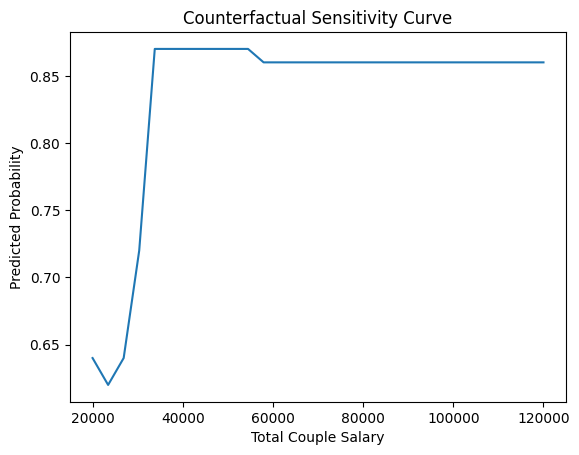

In [37]:
values = np.linspace(20000, 120000, 30)

probs = sensitivity_curve(
    x_new,
    "total_couple_salary",
    values,
    model,
    feature_names
)
plt.figure()
plt.plot(values, probs)
plt.xlabel("Total Couple Salary")
plt.ylabel("Predicted Probability")
plt.title("Counterfactual Sensitivity Curve")
plt.show()

In [38]:
def find_minimum_for_target(x, feature_name, target_prob,
                            value_range, model, feature_names):
    """
    Trova il minimo valore della feature che raggiunge target_prob.
    """

    x = ensure_2d(x)
    idx = feature_names.index(feature_name)

    for v in value_range:
        x_temp = x.copy()
        x_temp[0, idx] = v

        df_temp = pd.DataFrame(x_temp, columns=feature_names)
        p = model.predict_proba(df_temp)[0, 1]

        if p >= target_prob:
            return v, p

    return None, None

In [39]:
v_star, p_star = find_minimum_for_target(
    x_new,
    "total_couple_salary",
    target_prob=0.85,
    value_range=values,
    model=model,
    feature_names=feature_names
)

print("Valore minimo:", round(v_star, 3))
print(f"Probabilità ottenuta:{p_star*100:.2f}%")

Valore minimo: 33793.103
Probabilità ottenuta:87.00%


## 4 - Adaptive Explanation

In [40]:
# Inserisci questa cella e eseguila per vedere la struttura della pipeline
from sklearn.compose import ColumnTransformer
import pprint

# Mostra i nomi dei passi e i tipi
pprint.pprint(pipeline.named_steps)

# Cerca dinamicamente un possibile preprocessor
def find_preprocessor_step(pipeline):
    """
    Ritorna (name, step) se trova uno step che sembra essere il preprocessor
    (es. ColumnTransformer o qualcosa con get_feature_names_out), altrimenti (None, None).
    """
    from sklearn.compose import ColumnTransformer
    for name, step in pipeline.named_steps.items():
        # ColumnTransformer esplicito
        if isinstance(step, ColumnTransformer):
            return name, step
        # qualunque step con get_feature_names_out presumibilmente è un trasformatore
        if hasattr(step, "get_feature_names_out"):
            return name, step
    return None, None

name, step = find_preprocessor_step(pipeline)
print("Detected preprocessor step:", name, type(step))

{'clf': RandomForestClassifier(class_weight={0.0: 0.671, 1.0: 1.957}, random_state=42)}
Detected preprocessor step: None <class 'NoneType'>


In [41]:
def generate_adaptive_explanation(
    x,
    pipeline,
    explainer,
    user_level="basic"
):

    # Assicuriamo formato corretto
    x_2d = ensure_2d(x)
    df = pd.DataFrame(x_2d, columns=pipeline.feature_names_in_)

    # Probabilità
    prob = pipeline.predict_proba(df)[0,1]

    # SHAP
    shap_output = explainer(df)

    # Caso classificazione binaria (3D)
    if len(shap_output.values.shape) == 3:
        shap_instance = shap_output.values[0,:,1]
    else:
        shap_instance = shap_output.values[0]

    # Feature names trasformate
    feature_names = pipeline.feature_names_in_

    if len(shap_instance) != len(feature_names):
        raise ValueError(
            f"Mismatch SHAP={len(shap_instance)} "
            f"vs features={len(feature_names)}"
        )

    # Feature più influente
    top_idx = np.argmax(np.abs(shap_instance))
    top_feature = feature_names[top_idx]
    top_shap = shap_instance[top_idx]

    # ---- Adattamento livello ----

    if user_level == "basic":
        explanation = (
            f"La probabilità stimata è {prob:.2f}. "
            f"La variabile più influente è '{top_feature}'."
        )

    elif user_level == "intermediate":
        explanation = (
            f"Probabilità: {prob:.3f}\n"
            f"Top feature trasformata: {top_feature}\n"
            f"SHAP contribution: {top_shap:.4f}"
        )

    elif user_level == "advanced":
        explanation = (
            f"Predicted probability: {prob:.4f}\n"
            f"Decomposition:\n"
            f"f(x) = E[f(x)] + Σ φ_i\n"
            f"Top transformed feature: {top_feature}\n"
            f"φ_i: {top_shap:.6f}"
        )

    return explanation

In [42]:
print(f"Spiegazione di livello base: {generate_adaptive_explanation(x_new,pipeline,explainer,user_level="basic")}\n")
print(f"Spiegazione di livello intermedio: {generate_adaptive_explanation(x_new,pipeline,explainer,user_level="intermediate")}\n")
print(f"Spiegazione di livello avanzato: {generate_adaptive_explanation(x_new,pipeline,explainer,user_level="advanced")}")

Spiegazione di livello base: La probabilità stimata è 0.86. La variabile più influente è 'years_of_relation'.

Spiegazione di livello intermedio: Probabilità: 0.860
Top feature trasformata: years_of_relation
SHAP contribution: 0.0882

Spiegazione di livello avanzato: Predicted probability: 0.8600
Decomposition:
f(x) = E[f(x)] + Σ φ_i
Top transformed feature: years_of_relation
φ_i: 0.088242


## Uncertainty Integration in Adaptive Explanation

In [43]:
import numpy as np

def compute_rf_uncertainty(pipeline, x):
    """
    Calcola media, std e intervallo di confidenza
    usando la distribuzione delle probabilità
    dei singoli alberi della RandomForest.
    """

    # reshape se necessario
    x_2d = np.array(x).reshape(1, -1)

    clf = pipeline.named_steps["clf"]

    # probabilità di classe 1 per ogni albero
    tree_probs = np.array([
        tree.predict_proba(x_2d)[0, 1]
        for tree in clf.estimators_
    ])

    mean_prob = tree_probs.mean()
    std_prob = tree_probs.std()

    # intervallo ~95%
    lower = mean_prob - 1.96 * std_prob
    upper = mean_prob + 1.96 * std_prob

    return mean_prob, std_prob, lower, upper

In [44]:
def generate_adaptive_explanation(
    x,
    pipeline,
    explainer,
    feature_names,   # <-- aggiunto esplicitamente
    user_level="basic"
):

    x_2d = np.array(x).reshape(1, -1)

    # Probabilità
    mean_prob = pipeline.predict_proba(x_2d)[0, 1]

    # SHAP
    shap_values = explainer(x_2d)

    # Se output è 3D → prendiamo classe 1
    if len(shap_values.values.shape) == 3:
        shap_instance = shap_values.values[0, :, 1]
    else:
        shap_instance = shap_values.values[0]

    names = feature_names

    top_idx = np.argmax(np.abs(shap_instance))
    top_feature = names[top_idx]

    # Forziamo float
    top_shap = float(shap_instance[top_idx])

    if user_level == "advanced":
        return (
            f"Mean probability: {mean_prob:.4f}\n"
            f"Top SHAP feature: {top_feature}\n"
            f"Contribution: {top_shap:.4f}"
        )

    elif user_level == "intermediate":
        return (
            f"Probabilità stimata: {mean_prob:.3f}\n"
            f"Variabile dominante: {top_feature}"
        )

    else:
        return (
            f"La probabilità stimata è {mean_prob:.2f}.\n"
            f"La variabile più importante è '{top_feature}'."
        )

In [45]:
print(generate_adaptive_explanation(
    x_new,
    pipeline,
    explainer,
    feature_names
))
print("")
print(generate_adaptive_explanation(
    x_new,
    pipeline,
    explainer,
    feature_names,
    user_level="intermediate"
))
print("")
print(generate_adaptive_explanation(
    x_new,
    pipeline,
    explainer,
    feature_names,
    user_level="advanced"
))

La probabilità stimata è 0.86.
La variabile più importante è 'years_of_relation'.

Probabilità stimata: 0.860
Variabile dominante: years_of_relation

Mean probability: 0.8600
Top SHAP feature: years_of_relation
Contribution: 0.0882


## 5 - RAG

In [46]:
documents = [
    {
        "id": "requisiti",
        "title": "Chi può Adottare: Requisiti per l’adozione",
        "source": "Presidenza del Consiglio dei Ministri - requisiti per l'adozione",
        "text": """
        I requisiti per l’adozione internazionale sono gli stessi che per l’adozione nazionale, e sono previsti dall’art. 6 della legge 184/83 (come modificata dalla legge 149/2001) che disciplina l’adozione e l’affidamento e che riteniamo utile riportare perché il suo contenuto interessa più di ogni altro le coppie. "L’adozione è permessa ai coniugi uniti in matrimonio da almeno tre anni, o che raggiungano tale periodo sommando alla durata del matrimonio il periodo di convivenza prematrimoniale, e tra i quali non sussista separazione personale neppure di fatto e che siano idonei ad educare, istruire ed in grado di mantenere i minori che intendano adottare."

        Riguardo all’età:
        la differenza minima tra adottante e adottato è di 18 anni;
        la differenza massima tra adottanti ed adottato è di 45 anni per uno dei coniugi, di 55 per l'altro. Tale limite è derogato se i coniugi adottano due o più fratelli, ed ancora se hanno un figlio minorenne naturale o adottivo.
        I limiti di età introdotti dalla legge hanno lo scopo di garantire all’adottato genitori idonei ad allevarlo e seguirlo fino all’età adulta, in una condizione analoga a quella di una genitorialità naturale. Poiché l'abbinamento con il bambino adottabile è deciso dall'Autorità straniera, i limiti che la legislazione italiana, ha spostato in avanti per permettere anche a coppie non giovani di adottare, hanno poca efficacia nella realtà perché la maggior parte dei paesi stranieri privilegia le coppie giovani.

        I requisiti per adottore:
        essere coniugati al momento della presentazione della dichiarazione di disponibilità;
        provare documentalmente o per testimonianza, ove il matrimonio sia stato contratto da meno di tre anni, la continua, stabile, perdurante convivenza antecedentemente alla celebrazione del matrimonio per un periodo almeno pari al complemento a 3 anni;
        non avere in corso nessun procedimento di separazione, nemmeno di fatto.
        Infine, gli aspiranti genitori adottivi devono essere idonei ad educare ed istruire, e in grado di mantenere i minori che intendono adottare.
        Per questi ultimi requisiti non si può procedere con una semplice verifica formale, ma occorre una valutazione più complessa “nel merito”, cioè nei contenuti e nelle modalità del rapporto di coppia, che viene espletata dai Tribunali per i minorenni e realizzata tramite i servizi socio-assistenziali degli Enti locali, anche in collaborazione con i servizi delle aziende sanitarie locali; e ciò perché l'interdisciplinarità è necessaria per un'osservazione corretta della relazione di coppia e della sua reale disponibilità ad accogliere un figlio, delle sue risorse a fronteggiare le eventuali difficoltà di inserimento.
        """
    },
    {
        "id": "titolo1",
        "title": "Principi Generali",
        "source": "Presidenza del Consiglio dei Ministri - principi generali",
        "text": """
        La Camera dei deputati ed il Senato della Repubblica hanno approvato;
        IL PRESIDENTE DELLA REPUBBLICA
        PROMULGA
        la seguente legge:

        Art. 1
        1. Il minore ha diritto di crescere ed essere educato nell'ambito della propria famiglia.
        2. Le condizioni di indigenza dei genitori o del genitore esercente la ((responsabilità)) genitoriale non possono essere di ostacolo all'esercizio del diritto del minore alla propria famiglia. A tal fine a favore della famiglia sono disposti interventi di sostegno e di aiuto.
        3. Lo Stato, le regioni e gli enti locali, nell'ambito delle proprie competenze, sostengono, con idonei interventi, nel rispetto della loro autonomia e nei limiti delle risorse finanziarie disponibili, i nuclei familiari a rischio, al fine di prevenire l'abbandono e di consentire al minore di essere educato nell'ambito della propria famiglia. Essi promuovono altresì iniziative di formazione dell'opinione pubblica sull'affidamento e l'adozione e di sostegno all'attività delle comunità di tipo familiare, organizzano corsi di preparazione ed aggiornamento professionale degli operatori sociali nonché incontri di formazione e preparazione per le famiglie e le persone che intendono avere in affidamento o in adozione minori.
        I medesimi enti possono stipulare convenzioni con enti o associazioni senza fini di lucro che operano nel campo della tutela dei minori e delle famiglie per la realizzazione delle attività di cui al presente comma.
        4. Quando la famiglia non è in grado di provvedere alla crescita e all'eduzione del minore, si applicano gli istituti di cui alla presente legge.
        5. Il diritto del minore a vivere, crescere ed essere educato nell'ambito di una famiglia è assicurato senza distinzione di sesso, di etnia, di età, di lingua, di religione e nel rispetto della identità culturale del minore e comunque non in contrasto con i principi fondamentali dell'ordinamento.
        """
    },
    {
        "id": "titolo1bis",
        "title": "Affidamento del minore",
        "source": "Presidenza del Consiglio dei Ministri - affidamento del minore",
        "text": """
        Questo Titolo disciplina l’affidamento familiare e comunitario come misura temporanea. Il minore temporaneamente privo di un ambiente familiare idoneo è affidato preferibilmente a una famiglia (meglio se con altri figli) o a una persona singola in grado di provvedere al suo mantenimento, educazione e istruzione. Se non è possibile l’affidamento in famiglia, il minore viene collocato in una comunità di tipo familiare o in un istituto di assistenza pubblica o privata, preferibilmente vicino al luogo di residenza della famiglia d’origine (per i bambini sotto i sei anni l’inserimento può avvenire solo in comunità familiare). Gli operatori delle comunità o degli istituti esercitano i poteri tutelari sul minore fino alla nomina di un tutore.
        L’affidamento familiare si realizza con un provvedimento del servizio sociale locale, previa manifestazione di consenso da parte dei genitori o del tutore, sentito il minore che ha compiuto 12 anni. Se manca l’assenso, interviene il Tribunale per i minorenni. Nel provvedimento di affidamento vengono indicate le motivazioni, i tempi e le modalità dell’affidamento, i poteri riconosciuti all’affidatario e le modalità con cui la famiglia d’origine può mantenere i rapporti con il minore. Il servizio sociale locale responsabile deve riferire periodicamente al giudice tutelare o al Tribunale minorile sul programma di assistenza. La legge stabilisce inoltre che l’affidamento sia inizialmente limitato a 24 mesi, prorogabili dal Tribunale solo se necessario per il recupero della famiglia d’origine.
        L’affidatario ha l’obbligo di accogliere il minore presso di sé e di provvedere al suo mantenimento, educazione e istruzione, seguendo le indicazioni dei genitori (se titolari della potestà) o del tutore. Il Tribunale per i minorenni vigila sul buon andamento dell’affidamento preadottivo, coinvolgendo il giudice tutelare e i servizi sociali locali. In caso di difficoltà di convivenza irreversibili, il Tribunale può convocare affidatari e minore (anche con l’aiuto di uno psicologo) e disporre interventi di sostegno; se le difficoltà non si risolvono, può revocare l’affidamento preadottivo con provvedimento motivato. In caso di revoca, si adottano nuovi provvedimenti di tutela a favore del minore (ad es. nuovo affidamento).
        """
    },
    {
        "id": "titolo2",
        "title": "Adozione",
        "source": "Presidenza del Consiglio dei Ministri - adozione",
        "text": """
        Il Titolo II regola l’istituto dell’adozione. È suddiviso in quattro Capi: il primo indica i requisiti degli adottanti; il secondo disciplina la dichiarazione di adottabilità del minore; il terzo riguarda l’affidamento preadottivo; il quarto descrive la pronuncia di adozione.
        """
    },
    {
        "id": "titolo2capo1",
        "title": "Disposizioni generali",
        "source": "Presidenza del Consiglio dei Ministri - disposizioni generali",
        "text": """
        L’adozione è consentita a coniugi sposati da almeno tre anni, che non siano in stato di separazione (neppure di fatto) negli ultimi tre anni. I coniugi devono essere affettivamente idonei e avere capacità economica sufficiente a provvedere al minore che intendono adottare. L’età dei coniugi deve eccedere di almeno 18 anni e non superare di 45 anni quella del bambino adottando. Sono possibili deroghe: ad esempio, se un solo coniuge ha più di 45 anni (fino a un massimo di 55) o se vi sono figli naturali, e la norma favorisce l’adozione simultanea di fratelli. In caso di adozione di minori oltre i 12 anni o con handicap grave, lo Stato, le Regioni e gli enti locali possono intervenire con specifiche misure di sostegno economico e di formazione fino alla maggiore età del bambino.

        L’art. 7 stabilisce infine i requisiti dell’adottando: l’adozione può essere pronunziata solo a favore di minori dichiarati adottabili (vedi Capo II). Se il bambino ha compiuto 14 anni deve prestare il proprio consenso personale (revocabile fino alla sentenza definitiva); se ha più di 12 anni deve comunque essere sentito. I più piccoli vengono ascoltati secondo la capacità di capire.
        """
    },
    {
        "id": "titolo2capo2",
        "title": "Dichiarazione di adottabilità",
        "source": "Presidenza del Consiglio dei Ministri - dichiarazione di adottabilità",
        "text": """
        Il minore viene dichiarato in stato di adottabilità quando il Tribunale per i minorenni accerta che si trova in condizione di abbandono: è cioè privo di assistenza materiale e morale da parte di coloro che dovrebbero prendersene cura (genitori o altri parenti), senza che ciò sia dovuto a cause transitorie di forza maggiore. Questa situazione si considera presente anche se il minore è stato collocato in affidamento familiare, in comunità di tipo familiare o in istituto.
        Chiunque rilevi casi di abbandono deve segnalarli all’autorità giudiziaria; in particolare pubblici ufficiali e incaricati di pubblico servizio hanno l’obbligo di riferire al Procuratore presso il Tribunale per i minorenni appena ne vengano a conoscenza. Gli istituti di assistenza e le comunità familiari trasmettono semestralmente al Procuratore elenchi dei minori ospitati, con informazioni sui rapporti familiari e sulle condizioni psicofisiche. In questo modo il Procuratore individua i minori effettivamente in condizione di abbandono e può richiedere al Tribunale la loro dichiarazione di adottabilità.
        All’inizio del procedimento, il Presidente del Tribunale per i minorenni (o un giudice delegato) provvede all’immediata apertura di un’istruttoria e può adottare provvedimenti urgenti a tutela del bambino (affidamenti, sospensione della potestà). Vengono condotte le indagini necessarie e si ascolta il minore, i genitori, il Pubblico Ministero e il tutore. L’obiettivo di questo Capo è accertare ufficialmente lo stato di abbandono, così da rendere il bambino adottabile secondo quanto previsto dalla legge.
        """
    },
    {
        "id": "titolo2capo3",
        "title": "Affidamento preadottivo",
        "source": "Presidenza del Consiglio dei Ministri - affidamento preadottivo",
        "text": """
        I coniugi che vogliono adottare devono presentare domanda al Tribunale per i minorenni, specificando eventualmente se intendono adottare fratelli o bambini con handicap. Il Tribunale verifica i requisiti degli adottanti e dispone le indagini sociali necessarie: queste valutano la capacità educativa, la situazione economica, le motivazioni della coppia, dandosi priorità ai casi più critici (es. bambini oltre 5 anni o con handicap grave). Le indagini devono concludersi entro circa 120 giorni (prorogabili di altri 120 se motivato).

        Terminata l’istruttoria, il Tribunale, in camera di consiglio e sentiti il Pubblico Ministero, gli eventuali parenti degli adottanti e il minore (se ha più di 12 anni), sceglie la coppia più idonea tra quelle richiedenti e dispone l’affidamento preadottivo. Se il bambino ha più di 14 anni, il suo consenso all’affidamento deve essere espresso. Con ordinanza motivata il Tribunale stabilisce le modalità dell’affidamento e assicura che il bambino non venga affidato da solo se è fratello di altri minori adottabili, salvo gravi motivi.

        Durante l’affidamento, il Tribunale informa regolarmente i coniugi sull’andamento delle indagini e vigila sul buon esito della convivenza, avvalendosi di psicologi o di servizi sociali se necessario. In caso di accertate difficoltà insanabili, il Tribunale può revocare l’affidamento preadottivo con decreto motivato. In tale caso, il bambino viene affidato a nuove misure protettive secondo le norme sui minorenni.
        """
    },
    {
        "id": "titolo2capo4",
        "title": "Adozione internazionale",
        "source": "Presidenza del Consiglio dei Ministri - adozione internazionale",
        "text": """
        Almeno un anno dopo l’inizio dell’affidamento preadottivo (o un termine diverso stabilito dal tribunale), quest’ultimo valuta se le condizioni restano favorevoli e decide sull’adozione. In camera di consiglio vengono sentiti i coniugi adottanti, il minore (almeno di 12 anni), il Pubblico Ministero, il tutore e chi ha vigilato sul caso. Il minore di 14 anni deve prestare consenso scritto all’adozione. Se esistono figli maggiorenni dei richiedenti, anch’essi devono essere ascoltati.

        Se il Tribunale pronuncia l’adozione, con sentenza definitiva il bambino diventa a tutti gli effetti figlio degli adottanti. Questo significa che acquisisce lo stato di figlio legittimo, assume e trasmette il cognome degli adottanti e gode di tutti i diritti ereditari (Art.27). Al contempo cessano i vincoli giuridici con la famiglia d’origine (restano solo i divieti di matrimonio previsti per gli adottati). Se invece il Tribunale rigetta l’adozione, decade l’affidamento preadottivo e si adottano altri provvedimenti di tutela nei confronti del minore. In ogni caso, l’ufficiale dello Stato Civile annota la pronuncia a margine dell’atto di nascita del bambino.
        """
    },
    {
        "id": "titolo3",
        "title": "Dichiarazione di adozione",
        "source": "Presidenza del Consiglio dei Ministri - dichiarazione di adozione",
        "text": """
        Questo Titolo si applica alle adozioni di minori stranieri e alle procedure internazionali di adozione. La legge afferma che l’adozione di minori stranieri deve svolgersi secondo i principi della Convenzione dell’Aja del 1993 sulla tutela dei minori. Per coordinare le adozioni internazionali è istituita presso la Presidenza del Consiglio dei Ministri la Commissione per le adozioni internazionali.

        La Commissione svolge funzioni di coordinamento e controllo: collabora con le autorità centrali di altri Stati aderenti alle convenzioni internazionali, propone accordi bilaterali e autorizza gli enti italiani abilitati all’adozione internazionale. Essa tiene un albo degli enti autorizzati, vigila sul loro operato (effettua verifiche periodiche, può revocare l’autorizzazione in caso di inadempienze). La Commissione promuove inoltre iniziative di formazione per gli operatori, garantisce omogeneità negli enti autorizzati sul territorio nazionale e favorisce la reciproca fiducia con i Paesi stranieri. Infine, garantisce le procedure per il trasferimento del minore in Italia con i suoi futuri genitori adottivi, in conformità ai trattati internazionali.
        """
    },
    {
        "id": "titolo3capo2",
        "title": "Espatrio di minori a scopo di adozione",
        "source": "Presidenza del Consiglio dei Ministri - espatrio di minori a scopo di adozione",
        "text": """
        Il Capo II disciplina la situazione opposta, cioè l’adozione di minori italiani da parte di persone residenti all’estero. I residenti all’estero (cittadini italiani o stranieri in Paesi convenzionati) che intendono adottare un bambino italiano devono presentare domanda al console italiano competente; il consolato la trasmette al Tribunale per i minorenni del luogo di residenza o ultimo domicilio del minore (in mancanza è competente il tribunale di Roma).
        Il console del luogo di residenza degli adottanti vigila sul buon andamento dell’affidamento preadottivo, anche avvalendosi di associazioni assistenziali italiane o straniere. Se insorgono difficoltà di ambientamento del bambino nella nuova famiglia o altri problemi, il console ne informa immediatamente il Tribunale italiano che ha disposto l’affidamento. Il console assicura infine che le decisioni italiane relative al minore siano eseguite all’estero e, se necessario, si occupa del rimpatrio del bambino. (Se il minore straniero viene adottato da italiani, le stesse funzioni del console sono svolte dall’autorità centrale straniera e dal suo ente autorizzato).
        """
    },
    {
        "id": "titolo4",
        "title": "Adozione in casi particolari",
        "source": "Presidenza del Consiglio dei Ministri - adozione in casi particolari",
        "text": """
        Il Titolo IV elenca le ipotesi eccezionali in cui è possibile adottare un minore anche senza tutte le condizioni ordinarie previste dal Titolo II. L’art. 44 stabilisce che il minore può essere adottato “in casi particolari” quando ricorre almeno una di queste situazioni:

        il bambino è orfano di entrambi i genitori ed è legato agli adottanti da vincolo di parentela fino al 6° grado o da un rapporto stabile e duraturo;

        il minore è figlio del coniuge del futuro adottante (ad esempio stepchild), ancorché già adottivo dell’altro coniuge;

        il minore è orfano di entrambi i genitori e rientra nelle condizioni di handicap previste dalla legge 104/1992;

        non è stato possibile svolgere un affidamento preadottivo (ad esempio per impedimenti della famiglia).

        Anche in questi casi l’adozione è consentita anche se gli adottanti hanno figli legittimi (comma 2). Se l’adottante è coniugato, entrambi i coniugi devono farne richiesta (comma 3).

        Le altre regole di garanzia si applicano ugualmente: il minore deve essere sentito se ha più di 12 anni e, se ha compiuto 14 anni, deve prestare il suo consenso (o il suo legale rappresentante se il minore è gravemente disabile). L’art. 46 richiede l’assenso dei genitori biologici e del coniuge del minore; se questo consenso è negato senza valida giustificazione, il Tribunale può comunque pronunciare l’adozione nell’interesse del minore, a meno che a rifiutare siano i genitori titolari della potestà.

        L’adozione in casi particolari produce i suoi effetti dalla sentenza: il minore diventa figlio legittimo degli adottanti, assumendo il loro cognome, e cessano i rapporti giuridici con la famiglia d’origine (salvo i soli divieti matrimoniali). Fino alla sentenza definitiva, adottanti e adottando possono revocare il consenso. Se uno dei coniugi muore dopo il consenso ma prima della sentenza, si può ugualmente procedere su richiesta dell’altro coniuge.
        """
    },
    {
        "id": "titolo5",
        "title": "Modifiche al codice civile",
        "source": "Presidenza del Consiglio dei Ministri - modifiche al codice civile",
        "text": """
        In questo Titolo sono riportate le modifiche al Libro I del Codice Civile che si rendono necessarie per aggiornare la disciplina della filiazione adottiva. Vengono aggiornati gli articoli del Titolo VIII (in particolare artt. 312-314 c.c. sulla filiazione adottiva), inserendo rinvii alla legge 184/1983, e abrogando commi ormai obsoleti (ad esempio i commi 2 e 3 degli artt. 293 e 296 c.c. e gli articoli 301, 302, 303, 308, 310 c.c.). Queste disposizioni tecniche non introducono nuovi istituti ma assicurano che il Codice Civile sia coerente con le norme sull’adozione e sull’affidamento della legge 184/1983.
        """
    },
    {
        "id": "titolo6",
        "title": "Norme finali, penali e transitorie",
        "source": "Presidenza del Consiglio dei Ministri - norme finali, penali e transitorie",
        "text": """
        Il Titolo VI contiene norme finali di coordinamento, disposizioni transitorie e sanzioni penali. Ad esempio, viene stabilito che nei registri delle tutele devono essere annotati anche i provvedimenti del Tribunale minorile di affidamento familiare. Le sanzioni penali servono a prevenire abusi: in particolare chiunque, in ragione della propria funzione, omette di segnalare alla Procura minorile una situazione di abbandono di minore di cui viene a conoscenza è punito con la reclusione fino a un anno. Chi affida un minore a terzi in modo permanente in violazione delle regole, o lo invia illecitamente all’estero per l’adozione, è punito con la reclusione da uno a tre anni. Se il colpevole è il tutore o una persona cui il bambino è affidato, le pene aumentano e si applicano misure accessorie (perdita della potestà, decadenza dal tutore, interdizione a contrarre affidamenti). Analogamente chi media illegalmente per collocare un minore in affidamento definitivo (pagando o promettendo denaro) rischia la reclusione fino a un anno o la multa. In tal modo la legge tutela il minore da azioni illecite in materia di affidamenti e adozioni. Infine, il Titolo VI disciplina il riconoscimento in Italia delle adozioni pronunciate all’estero, disponendo l’annotazione necessaria negli atti di stato civile.
        """
    },

]

In [47]:
from sentence_transformers import SentenceTransformer
import numpy as np

model_embed = SentenceTransformer("all-MiniLM-L6-v2")

corpus_texts = [doc["text"] for doc in documents]
corpus_embeddings = model_embed.encode(corpus_texts)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [48]:
def retrieve_documents(query, top_k=2):
    query_embedding = model_embed.encode([query])[0]

    similarities = np.dot(corpus_embeddings, query_embedding)
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    retrieved_docs = [documents[i] for i in top_indices]

    return retrieved_docs

In [49]:
def generate_rag_explanation(user_query):

    retrieved_docs = retrieve_documents(user_query)

    context = "\n\n".join(
        [f"{doc['title']} ({doc['source']}):\n{doc['text']}"
         for doc in retrieved_docs]
    )

    prompt = f"""
    Usa SOLO le informazioni nei documenti seguenti.
    Cita esplicitamente la fonte tra parentesi.

    Documenti:
    {context}

    Domanda:
    {user_query}

    Risposta:
    """

    response = llm_client.chat_completion(model="meta-llama/Llama-3.1-8B-Instruct", messages=[{"role": "user","content": prompt}])

    return response, retrieved_docs

In [50]:
prompt="Siamo una coppia sposata da 10 anni composta da un uomo di 37 e una donna di 35 anni. Siamo entrambi laureati e abbiamo entrambi un contratto a tempo indeterminato. Abbiamo un reddito di 57084.3 euro annuali e una casa di proprietà di 76.3 metri quadrati."
response, retrieved_docs = generate_rag_explanation(prompt)
print(response.choices[0].message.content)

Dati i tuoi requisiti, sembrano in ordine per provare a fare richiesta per adottare un bambino ad altri Stati.

*   I coniugi sono sposati da almeno 10 anni, quindi il requisito di 3 anni è superato [1].
*   Non ci sono problemi di separazione personale o di fatto.
*   L'età di uno dei coniugi non supera i 45 anni: in particolare, l'uomo ha 37 anni e la donna ha 35 anni. Però, la donna ha passato i 45 anni e luomo era 7.


## 6 - UPDATED PLATFORM

In [51]:
# =================== AIDOPTION — FINAL DASHBOARD (with adaptive explanations & OOD explanation) ===================
import traceback, textwrap, math, time
import numpy as np
import pandas as pd
import gradio as gr
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ----------------- Safety checks & small helpers -----------------
def _diag_msg(s):
    return f"**(diagnostic)** {s}"

if 'FEATURE_NAMES' not in globals():
    raise RuntimeError("FEATURE_NAMES not found in global namespace. Define it (list of dataset columns).")

# model/pipeline
if 'model' not in globals():
    if 'pipeline' in globals():
        model = globals()['pipeline']
    else:
        raise RuntimeError("No model/pipeline found in memory. Load or define 'model' or 'pipeline' before running this cell.")

# flags
HAS_RF_CALIB = 'rf_calibrated' in globals()
HAS_EXPLAINER = 'explainer' in globals()
HAS_LLM = ('llm_client' in globals() and llm_client is not None)
HAS_RAG = all(k in globals() for k in ('documents','model_embed','corpus_embeddings')) and HAS_LLM
HAS_XDF = 'X_df' in globals() or ('X' in globals() and isinstance(globals()['X'], pd.DataFrame))

# Minimal config
NON_MODIFIABLE = set(globals().get('NON_MODIFIABLE_FEATURES', ['age_parent_1','age_parent_2','mean_age_parents']))
MIN_DELTA = float(globals().get('CF_MIN_DELTA', 0.01))
TOP_K_SUGGESTIONS = int(globals().get('TOP_K_SUGGESTIONS', 5))

# Cache for OOD thresholds to avoid recomputing
_ood_stats = None
_ood_stats_ts = None

# ----------------- Utilities (robust) -----------------
def preprocess_input_minimal(raw_dict):
    df = pd.DataFrame([raw_dict])
    # compute mean_age_parents if required
    if 'mean_age_parents' in FEATURE_NAMES:
        try:
            a1 = pd.to_numeric(df.get('age_parent_1'), errors='coerce') if 'age_parent_1' in df.columns else None
            a2 = pd.to_numeric(df.get('age_parent_2'), errors='coerce') if 'age_parent_2' in df.columns else None
            if a1 is not None and a2 is not None:
                df['mean_age_parents'] = (a1 + a2) / 2
            elif a1 is not None:
                df['mean_age_parents'] = a1
            elif a2 is not None:
                df['mean_age_parents'] = a2
        except Exception:
            df['mean_age_parents'] = np.nan
    # ensure cols
    for feat in FEATURE_NAMES:
        if feat not in df.columns:
            df[feat] = np.nan
    df = df[FEATURE_NAMES]
    # cast types
    for feat in FEATURE_NAMES:
        ftype = FEATURE_TYPES.get(feat, "numeric")
        if ftype == "numeric":
            df[feat] = pd.to_numeric(df[feat], errors='coerce')
        elif isinstance(ftype, list):
            df[feat] = df[feat].astype(str)
        else:
            df[feat] = df[feat].astype(str)
    return df

def predict_proba_df_safe(X_df):
    try:
        return np.array(model.predict_proba(X_df)[:,1])
    except Exception:
        return np.array(model.predict_proba(X_df.values)[:,1])

def compute_rf_uncertainty(pipeline_or_clf, x):
    try:
        x_arr = np.array(x).reshape(1, -1)
    except Exception:
        return (None,None,None,None)
    clf = None
    if hasattr(pipeline_or_clf, "named_steps"):
        clf = pipeline_or_clf.named_steps.get("clf", None)
    if clf is None and hasattr(pipeline_or_clf, "estimators_"):
        clf = pipeline_or_clf
    if clf is None or not hasattr(clf, "estimators_"):
        return (None,None,None,None)
    tree_probs = np.array([t.predict_proba(x_arr)[0,1] for t in clf.estimators_])
    mean_prob = float(tree_probs.mean()); std_prob = float(tree_probs.std())
    lower = max(0.0, mean_prob - 1.96 * std_prob); upper = min(1.0, mean_prob + 1.96 * std_prob)
    return mean_prob, std_prob, lower, upper

# OOD NN & thresholds
_nn_obj = None
def _compute_ood_stats(refresh=False):
    """
    Compute and cache distributional statistics of per-sample mean distance
    inside the training set so we can explain OOD score thresholds.
    """
    global _ood_stats, _ood_stats_ts, _nn_obj
    if not HAS_XDF:
        return None
    if _ood_stats is not None and not refresh:
        return _ood_stats
    try:
        # get training dataframe to compute reference distances
        train_df = X_df if 'X_df' in globals() else (globals().get('X') if isinstance(globals().get('X'), pd.DataFrame) else None)
        if train_df is None or len(train_df) < 10:
            return None
        # fit NN on train data if not already
        _nn_obj = NearestNeighbors(n_neighbors=6).fit(train_df.values)
        dists, idxs = _nn_obj.kneighbors(train_df.values)
        # dists[:,0] are zeros (self), so take mean across columns 1..5
        mean_neigh = dists[:,1:].mean(axis=1)
        p25, p50, p75 = np.percentile(mean_neigh, [25, 50, 75])
        _ood_stats = {"p25":float(p25), "p50":float(p50), "p75":float(p75)}
        _ood_stats_ts = time.time()
        return _ood_stats
    except Exception:
        return None

def compute_ood_score_with_explanation(x):
    """
    Returns: (ood_value, label, explanation_string)
    label: one of 'low','moderate','high' w.r.t training distribution
    """
    global _nn_obj
    try:
        x_arr = np.array(x).reshape(1, -1)
    except Exception:
        return None, None, "OOD score not available"
    # ensure NN fit to train data
    train_df = None
    if 'X_df' in globals():
        train_df = X_df
    elif 'X' in globals() and isinstance(globals()['X'], pd.DataFrame):
        train_df = globals()['X']
    if train_df is None:
        # fallback heuristic
        try:
            # compute distance to 5 nearest in model-fitting space if _nn_obj present
            if _nn_obj is None:
                _nn_obj = NearestNeighbors(n_neighbors=5).fit(np.zeros((1, x_arr.shape[1])))
            dists, _ = _nn_obj.kneighbors(x_arr)
            val = float(dists.mean())
            # heuristic thresholds
            if val <= 0.5:
                label = "low (similar to training)"
            elif val <= 1.5:
                label = "moderate"
            else:
                label = "high (dissimilar to training)"
            expl = f"OOD value {val:.3f}. (Heuristic scale: lower = more similar to training examples.)"
            return val, label, expl
        except Exception:
            return None, None, "OOD score not available"
    # compute sample mean distance to 5 nearest training neighbors
    try:
        if _nn_obj is None:
            _nn_obj = NearestNeighbors(n_neighbors=5).fit(train_df.values)
        dists, _ = _nn_obj.kneighbors(x_arr)
        val = float(dists.mean())
        stats = _compute_ood_stats()
        if stats:
            p25, p50, p75 = stats['p25'], stats['p50'], stats['p75']
            if val <= p50:
                label = "low (similar to training)"
            elif val <= p75:
                label = "moderate (somewhat different)"
            else:
                label = "high (dissimilar to training)"
            expl = (f"OOD value {val:.3f}. Relative to training set: 25th={p25:.3f}, 50th={p50:.3f}, 75th={p75:.3f}. "
                    f"A lower value indicates the sample is more similar to training data.")
        else:
            # fallback labels
            if val <= 0.5:
                label = "low (similar to training)"
            elif val <= 1.5:
                label = "moderate"
            else:
                label = "high (dissimilar to training)"
            expl = f"OOD value {val:.3f}. (No training thresholds available.)"
        return val, label, expl
    except Exception:
        return None, None, "OOD score not available"

# Counterfactual effect single feature
def counterfactual_effect(x, model_obj, feature_names, feature_to_change, new_value):
    x_arr = np.array(x)
    if x_arr.ndim == 1:
        x_arr = x_arr.reshape(1, -1)
    try:
        original_prob = float(model_obj.predict_proba(x_arr)[0,1])
    except Exception:
        original_prob = float(model_obj.predict_proba(pd.DataFrame(x_arr, columns=feature_names))[0,1])
    x_cf = x_arr.copy()
    idx = feature_names.index(feature_to_change)
    x_cf[0, idx] = new_value
    try:
        new_prob = float(model_obj.predict_proba(x_cf)[0,1])
    except Exception:
        new_prob = float(model_obj.predict_proba(pd.DataFrame(x_cf, columns=feature_names))[0,1])
    return original_prob, new_prob, new_prob - original_prob

def find_minimum_for_target(x, feature_name, target_prob, value_range, model_obj, feature_names):
    x_arr = np.array(x)
    if x_arr.ndim == 1:
        x_arr = x_arr.reshape(1, -1)
    idx = feature_names.index(feature_name)
    for v in value_range:
        x_temp = x_arr.copy()
        x_temp[0, idx] = v
        try:
            p = float(model_obj.predict_proba(x_temp)[0,1])
        except Exception:
            p = float(model_obj.predict_proba(pd.DataFrame(x_temp, columns=feature_names))[0,1])
        if p >= target_prob:
            return v, p
    return None, None

# RAG + LLM helpers (adaptive to user_level)
def call_llm(messages, model_name=None, max_tokens=512, temperature=0.0, user_level=None):
    """
    messages: list of dicts like [{"role":"system","content":...},{"role":"user","content":...}]
    If user_level is set, prepend a system message with style instructions.
    """
    if not HAS_LLM:
        return None
    style_map = {
        "basic": "Use simple, non-technical language. Short sentences. Define any technical term in plain words.",
        "intermediate": "Use moderate technical language with brief clarifications. Assume some familiarity with ML concepts.",
        "advanced": "Provide a detailed technical explanation with methodological specifics and metrics."
    }
    style_msg = None
    if user_level in style_map:
        style_msg = {"role":"system", "content": f"Adapt the answer to the user's expertise level: {user_level}. {style_map[user_level]}"}
    # construct final messages
    final_messages = []
    if style_msg:
        final_messages.append(style_msg)
    final_messages.extend(messages)
    try:
        resp = llm_client.chat_completion(messages=final_messages, model=(model_name or LLM_MODEL), max_tokens=max_tokens, temperature=temperature)
        if isinstance(resp, dict) and "choices" in resp and resp["choices"]:
            ch = resp["choices"][0]
            msg = ch.get("message") if isinstance(ch, dict) else ch
            if isinstance(msg, dict) and "content" in msg:
                return msg["content"].strip()
        if isinstance(resp, str):
            return resp.strip()
        if hasattr(resp, "generations"):
            gen = resp.generations
            if gen and isinstance(gen[0], dict) and "text" in gen[0]:
                return gen[0]["text"].strip()
        return str(resp)
    except Exception:
        traceback.print_exc()
        return None

def generate_rag_question_via_llm(applicant_recap, prob, top_features, user_level="intermediate"):
    """
    Ask the LLM to produce a concise focused question for RAG retrieval.
    """
    if not HAS_LLM:
        feats = ", ".join(top_features[:3]) if top_features else ""
        return f"How do {feats} influence adoption approval under current norms and guidelines?"
    system = {"role":"system", "content":"You are an assistant that creates a concise, focused retrieval query to fetch authoritative documents (legal/regulatory/practice) relevant to adoption decisions."}
    user_text = f"Applicant recap:\n{applicant_recap}\n\nModel predicted probability: {prob*100:.1f}%\nTop features: {', '.join(top_features)}\n\nProduce a 1-2 sentence question to be used to retrieve documents explaining how these features relate to adoption approval (legal/regulatory/practice). Keep it objective and focused."
    user = {"role":"user", "content": user_text}
    resp = call_llm([system, user], max_tokens=160, temperature=0.0, user_level=user_level)
    if resp and isinstance(resp, str) and len(resp.strip())>10:
        return resp.strip()
    feats = ", ".join(top_features[:3]) if top_features else ""
    return f"How do {feats} influence adoption approval under current norms and guidelines?"

def generate_rag_explanation(user_query, prediction=None, uncertainty=None, applicant_recap=None, top_k=3, user_level="intermediate"):
    """
    Retrieve docs for user_query and call LLM to produce justification that cites docs.
    Instruction: documents do not need to explicitly mention a phrase to be cited; semantic coherence/correlation is sufficient.
    """
    retrieved = retrieve_documents(user_query, top_k=top_k) if HAS_RAG else []
    context_parts = []
    for i, d in enumerate(retrieved):
        title = d.get("title", "Untitled")
        source = d.get("source", "Unknown source")
        text = d.get("text", "")
        context_parts.append(f"[DOC {i+1}] {title} (Source: {source})\n{text}")
    context = "\n\n".join(context_parts)
    prompt = "You are an assistant that must use ONLY the provided documents to justify model explanations and cite them inline.\n\n"
    if applicant_recap:
        prompt += f"Applicant recap:\n{applicant_recap}\n\n"
    prompt += f"Prediction: {prediction}\nUncertainty: {uncertainty}\n\nDocuments:\n{context}\n\nQuestion:\n{user_query}\n\nInstructions:\n- Use only the documents above.\n- It is not necessary that a document explicitly mentions a specific feature by name; it is acceptable to cite documents that are semantically coherent and show correlation/relevance.\n- Cite sources inline using format: (Source: <source name>)\n- Do not invent sources.\n- Keep the answer concise (3-6 short paragraphs) and explicitly mention which document supports each claim.\n"
    system = {"role":"system", "content":"You are a concise assistant that cites document sources when supporting claims."}
    if HAS_LLM:
        resp = call_llm([system, {"role":"user","content":prompt}], max_tokens=700, temperature=0.0, user_level=user_level)
        return resp, retrieved
    else:
        return None, retrieved

# Detect properties
def detect_feature_properties(feat):
    info = {"kind":"unknown", "lower":None, "upper":None, "is_integer":False}
    if feat in FEATURE_RANGES:
        lo, hi = FEATURE_RANGES.get(feat)
        try:
            info['lower'] = float(lo) if lo is not None else None
            info['upper'] = float(hi) if hi is not None else None
        except Exception:
            info['lower'], info['upper'] = None, None
    if 'X_df' in globals():
        try:
            ser = X_df[feat].dropna()
            unique_vals = pd.unique(ser)
            if len(unique_vals) <= 2:
                info['kind'] = 'binary'
                try:
                    vals = sorted([float(x) for x in unique_vals])
                    info['lower'], info['upper'] = vals[0], vals[-1]
                except Exception:
                    pass
                info['is_integer'] = all(float(x).is_integer() for x in unique_vals)
                return info
            if isinstance(FEATURE_TYPES.get(feat, None), list):
                info['kind'] = 'categorical'
                return info
            if pd.api.types.is_integer_dtype(ser) or pd.api.types.is_float_dtype(ser):
                info['kind'] = 'continuous'
                info['is_integer'] = pd.api.types.is_integer_dtype(ser)
                if info['lower'] is None:
                    info['lower'], info['upper'] = float(ser.min()), float(ser.max())
                return info
        except Exception:
            pass
    ftype = FEATURE_TYPES.get(feat, "numeric")
    if isinstance(ftype, list):
        info['kind'] = 'categorical'
    elif ftype == 'numeric':
        info['kind'] = 'continuous'
    else:
        info['kind'] = 'unknown'
    return info

# ----------------- UI BUILD: CSS + inputs -----------------
css = """
.card { background: linear-gradient(180deg,#0f1720,#0b1220); color: #e6eef8; border-radius: 12px; padding: 16px; box-shadow: 0 6px 18px rgba(0,0,0,0.45); border:1px solid rgba(255,255,255,0.03);}
.prob-card { padding:18px; border-radius:12px; text-align:center; background: linear-gradient(90deg, rgba(255,255,255,0.03), rgba(255,255,255,0.01)); }
.small-muted { color: #9aa4b2; font-size:0.9rem; }
.progress { width:100%; height:14px; border-radius:8px; overflow:hidden; background:#1f2937; }
.progress > div { height:100%; transition: width 0.3s ease; }
.prob-title { color: #cbd5e1; margin:0; font-weight:600; }
.prob-value { margin:4px 0 8px 0; font-size:28px; font-weight:700; color:#ffffff; }
"""

input_feature_list = [f for f in FEATURE_NAMES if f != 'mean_age_parents']

inputs_components = []
for feat in input_feature_list:
    ftype = FEATURE_TYPES.get(feat, "numeric")
    desc = FEATURE_DESCRIPTIONS.get(feat, feat) if 'FEATURE_DESCRIPTIONS' in globals() else feat
    if isinstance(ftype, list):
        inputs_components.append(gr.Dropdown(choices=[str(x) for x in ftype], label=feat, info=desc))
    elif ftype == "numeric":
        inputs_components.append(gr.Number(value=0, label=feat, info=desc))
    else:
        inputs_components.append(gr.Textbox(label=feat, info=desc))

# user_level selector (adaptive explanation)
user_level_component = gr.Radio(choices=["basic","intermediate","advanced"], value="intermediate", label="Expertise level (controls explanation complexity)")

# Outputs
prob_html = gr.HTML()
uncertainty_md = gr.Markdown()
shap_plot = gr.Plot()
cf_table = gr.Dataframe(headers=["feature","current","suggested","new_prob","delta_prob"], label="Counterfactual suggestions")
cf_disclaimer_out = gr.Markdown()
rag_md = gr.Markdown()
llm_md = gr.Markdown()
diag_md = gr.Markdown()

# Helper: generate applicant recap (adaptive)
def generate_applicant_recap_text(raw_input_dict, prob=None, uncertainty=None, user_level="intermediate"):
    if not HAS_LLM or llm_client is None:
        lines = []
        for k,v in raw_input_dict.items():
            lines.append(f"{k}: {v}")
        if prob is not None:
            lines.append(f"Model predicted probability: {prob*100:.1f}%")
        if uncertainty is not None:
            lines.append(f"Estimated uncertainty (std): {uncertainty:.3f}")
        return "\n".join(lines)
    system_msg = {"role":"system","content":"You are a concise summarizer. Produce a short (3-6 sentence) applicant summary focusing on facts relevant to adoption: ages, relationship length, housing, income and risk flags."}
    prioritized = ['age_parent_1','age_parent_2','years_of_relation','total_couple_salary','house_square_meters','number_of_rooms','criminal_record_num']
    user_lines = []
    for f in prioritized:
        if f in raw_input_dict:
            user_lines.append(f"{f}: {raw_input_dict.get(f)}")
    added = 0
    for f,v in raw_input_dict.items():
        if f in prioritized:
            continue
        if added >= 4:
            break
        user_lines.append(f"{f}: {v}")
        added += 1
    if prob is not None:
        user_lines.append(f"Model probability: {prob*100:.1f}%")
    if uncertainty is not None:
        user_lines.append(f"Uncertainty std: {uncertainty:.3f}")
    user_msg = {"role":"user","content":"\n".join(user_lines) + "\n\nPlease produce a short 3-6 sentence summary usable to contextualize a normative explanation."}
    resp = call_llm([system_msg, user_msg], max_tokens=220, temperature=0.0, user_level=user_level)
    return resp if resp else "\n".join(user_lines)

# ----------------- Main predict function -----------------
def predict_dashboard(*args):
    """
    args structure: [<inputs...>, use_llm_bool, user_level]
    """
    try:
        if len(args) < len(input_feature_list) + 2:
            raise ValueError("Insufficient inputs: ensure you provide feature inputs, use_llm toggle, and user_level.")
        use_llm = bool(args[len(input_feature_list)])
        user_level = args[len(input_feature_list) + 1]
        # build raw dict from first N args
        raw = { input_feature_list[i]: args[i] for i in range(len(input_feature_list)) }
        df = preprocess_input_minimal(raw)
        # predict
        if HAS_RF_CALIB:
            try:
                prob = float(rf_calibrated.predict_proba(df)[0,1])
            except Exception:
                prob = float(predict_proba_df_safe(df)[0])
        else:
            prob = float(predict_proba_df_safe(df)[0])
        # uncertainty & ood
        mean_rf, std_rf, lower_ci, upper_ci = compute_rf_uncertainty(model, df.values)
        ood_val, ood_label, ood_expl = compute_ood_score_with_explanation(df.values)
        # SHAP
        shap_vals = None
        if HAS_EXPLAINER:
            try:
                sv = explainer(df)
                if hasattr(sv, "values"):
                    vals = np.array(sv.values)
                    shap_vals = vals[0,:,1] if vals.ndim==3 else vals[0,:]
            except Exception:
                shap_vals = None

        # ----------------- Robust CF generation (only positive deltas > MIN_DELTA) -----------------
        candidate_list = []
        base_prob = prob
        if shap_vals is not None:
            neg_idx = np.argsort(shap_vals)[:TOP_K_SUGGESTIONS*3]  # candidates
            considered = 0
            for idx in neg_idx:
                if considered >= TOP_K_SUGGESTIONS:
                    break
                fname = FEATURE_NAMES[idx]
                # detect properties
                prop = detect_feature_properties(fname)
                kind = prop.get("kind","unknown")
                lo, hi = prop.get("lower"), prop.get("upper")
                is_int = prop.get("is_integer", False)
                # current
                try:
                    current_raw = df.iloc[0][fname]
                    if pd.isna(current_raw):
                        continue
                    current = float(current_raw)
                except Exception:
                    continue
                # skip non-actionable immutables for suggestions (but user wanted no limits — however unrealistic suggestions must be avoided)
                if fname in NON_MODIFIABLE:
                    continue
                # build candidate_values depending on kind
                candidate_values = []
                if kind == "binary":
                    if current in (0,1):
                        candidate_values = [1.0 - current]
                    else:
                        continue
                elif kind == "continuous":
                    if lo is not None and hi is not None and lo < hi:
                        grid = np.linspace(lo, hi, 40)
                        v_star, p_star = find_minimum_for_target(df.values, fname, target_prob=0.8, value_range=grid, model_obj=model, feature_names=FEATURE_NAMES)
                        if v_star is not None:
                            candidate_values.append(float(v_star))
                        step = max((hi - lo) * 0.10, 1e-6)
                        up = min(hi, current + step)
                        down = max(lo, current - step)
                        if abs(up - current) > 1e-9:
                            candidate_values.append(float(up))
                        if abs(down - current) > 1e-9:
                            candidate_values.append(float(down))
                    else:
                        up = current * 1.10
                        down = current * 0.90
                        if abs(current) < 1e-9:
                            up = 1.0
                        candidate_values = [up, down]
                else:
                    # skip categorical / unknown candidates (could add categorical flips later)
                    continue

                # normalize & evaluate
                filtered = []
                for cand in candidate_values:
                    if lo is not None and cand < lo - 1e-9:
                        cand = lo
                    if hi is not None and cand > hi + 1e-9:
                        cand = hi
                    if is_int:
                        cand = float(int(round(cand)))
                    if abs(cand - current) < 1e-9:
                        continue
                    if kind == "binary" and cand not in (0.0,1.0):
                        continue
                    try:
                        orig_p, new_p, delta = counterfactual_effect(df.values, model, FEATURE_NAMES, fname, cand)
                    except Exception:
                        continue
                    # keep only positive improvements above MIN_DELTA
                    if delta is None:
                        continue
                    if delta <= MIN_DELTA:
                        continue
                    if abs(new_p - orig_p) < 1e-9:
                        continue
                    filtered.append({
                        "feature": fname,
                        "current": float(current),
                        "suggested": float(cand),
                        "new_prob": float(new_p),
                        "delta_prob": float(delta),
                        "abs_delta": abs(delta)
                    })
                if filtered:
                    df_f = pd.DataFrame(filtered).sort_values('abs_delta', ascending=False).iloc[0]
                    candidate_list.append(df_f.to_dict())
                    considered += 1
        else:
            # fallback attempt
            if "total_couple_salary" in FEATURE_NAMES:
                try:
                    cur = float(df.iloc[0]["total_couple_salary"])
                    lo_hi = FEATURE_RANGES.get("total_couple_salary", (None,None))
                    lo, hi = lo_hi
                    cand = cur * 1.10
                    if hi is not None:
                        cand = min(cand, float(hi))
                    orig_p, new_p, delta = counterfactual_effect(df.values, model, FEATURE_NAMES, "total_couple_salary", cand)
                    if delta is not None and delta > MIN_DELTA:
                        candidate_list.append({"feature":"total_couple_salary","current":float(cur),"suggested":float(cand),"new_prob":float(new_p),"delta_prob":float(delta),"abs_delta":abs(delta)})
                except Exception:
                    pass

        # prepare final CF df: keep top-K by delta_prob, only delta > MIN_DELTA (positive)
        if candidate_list:
            cf_df = pd.DataFrame(candidate_list)
            cf_df = cf_df.loc[ cf_df['delta_prob'] > MIN_DELTA ]
            if not cf_df.empty:
                cf_df = cf_df.sort_values('abs_delta', ascending=False).drop_duplicates(subset=['feature'], keep='first')
                cf_df = cf_df.sort_values('abs_delta', ascending=False).head(TOP_K_SUGGESTIONS)
                final_cf_df = cf_df.drop(columns=['abs_delta']).reset_index(drop=True)
            else:
                final_cf_df = pd.DataFrame([], columns=["feature","current","suggested","new_prob","delta_prob"])
        else:
            final_cf_df = pd.DataFrame([], columns=["feature","current","suggested","new_prob","delta_prob"])

        # Build SHAP plot
        if shap_vals is not None:
            abs_idx = np.argsort(np.abs(shap_vals))[::-1][:10]
            labels = [FEATURE_NAMES[i] for i in abs_idx]
            vals_plot = shap_vals[abs_idx]
            fig, ax = plt.subplots(figsize=(6,3))
            ax.barh(range(len(labels))[::-1], vals_plot[::-1], color="#60a5fa")
            ax.set_yticks(range(len(labels)))
            ax.set_yticklabels(labels[::-1], color="#e6eef8")
            ax.set_xlabel("SHAP value (contribution)", color="#cbd5e1")
            ax.set_title("Top feature contributions (local SHAP)", color="#e6eef8")
            ax.tick_params(axis='x', colors='#cbd5e1')
            fig.patch.set_facecolor('#0b1220'); ax.set_facecolor('#0b1220'); plt.tight_layout()
        else:
            fig = plt.figure(figsize=(6,3)); fig.patch.set_facecolor('#0b1220'); plt.text(0.5,0.5,"SHAP not available", ha="center", color="#e6eef8"); plt.axis('off')

        # Applicant recap for RAG
        applicant_recap = generate_applicant_recap_text(raw_input_dict=raw, prob=prob, uncertainty=std_rf, user_level=user_level)

        # ---------- RAG flow: LLM creates focused retrieval question -> retrieve -> explain ----------
        rag_block = ""
        if HAS_RAG and HAS_LLM:
            top_feats = list(final_cf_df['feature'].values) if not final_cf_df.empty else []
            try:
                rag_question = generate_rag_question_via_llm(applicant_recap, prob, top_feats, user_level=user_level)
            except Exception:
                rag_question = None
            if not rag_question:
                rag_question = "How do parents' ages and years_of_relation affect adoption approval?"
            try:
                rag_answer, retrieved = generate_rag_explanation(rag_question, prediction=prob, uncertainty=std_rf, applicant_recap=applicant_recap, top_k=3, user_level=user_level)
            except Exception:
                traceback.print_exc(); rag_answer, retrieved = None, []
            if rag_answer:
                rag_block += f"**RAG justification (contextualized):**\n\n{rag_answer}\n\n"
                if retrieved:
                    rag_block += "**Sources:**\n"
                    for d in retrieved:
                        rag_block += f"- {d.get('title','(no title)')} ({d.get('source','unknown')})\n"
        else:
            rag_block = _diag_msg("RAG corpus or LLM not configured.")

        # ---------- LLM interpretation: enforce realism & adapt to user_level ----------
        llm_block = ""
        if use_llm and HAS_LLM:
            system_msg = {
                "role":"system",
                "content":(
                    "You are an assistant that translates model-based suggestions into practical, realistic advice. "
                    "DO NOT recommend changing immutable attributes (e.g., age_parent_1, age_parent_2, mean_age_parents, gender). "
                    "If a suggestion would require an impossible or unethical action (e.g., lowering someone's age), explicitly refuse and propose realistic alternatives (e.g., improving health indicators, securing stable income, legal/administrative steps, housing improvements). "
                    "Prefer feasible interventions and mention feasibility/cost when relevant. Keep answers concise and grounded."
                )
            }
            user_lines = [f"Applicant recap:\n{applicant_recap}", f"Model predicted probability: {prob*100:.1f}%"]
            if std_rf is not None:
                user_lines.append(f"Estimated uncertainty (std across trees): {std_rf:.3f}. 95% CI: [{lower_ci:.3f},{upper_ci:.3f}]")
            if ood_val is not None:
                user_lines.append(f"OOD: {ood_label}. {ood_expl}")
            user_lines.append("\nCounterfactual suggestions (only positive impacts):")
            summary_list = final_cf_df.to_dict(orient='records') if not final_cf_df.empty else []
            if not summary_list:
                user_lines.append("None (no positive candidate with sufficient effect).")
            else:
                for s in summary_list:
                    user_lines.append(f"- {s['feature']}: {s['current']} -> {s['suggested']} (new_prob {s['new_prob']*100:.2f}%, Δ {s['delta_prob']*100:.2f}%)")
            user_lines.append("\nFor each suggestion produce 1-2 practical sentences explaining why this could increase the probability, realistic feasibility notes, and 3 prioritized recommendations. Do NOT suggest impossible changes to immutable features.")
            user_msg = {"role":"user", "content":"\n".join(user_lines)}
            resp = call_llm([system_msg, user_msg], max_tokens=800, temperature=0.0, user_level=user_level)
            llm_block = resp if resp else _diag_msg("LLM returned no textual interpretation.")
        else:
            llm_block = _diag_msg("LLM disabled or not configured.")

        # ---------- Prepare OOD & uncertainty text for user-friendly presentation ----------
        ood_present_text = ""
        if ood_val is not None:
            # give textual guidance
            ood_present_text = f"**OOD (out-of-distribution) score**: {ood_val:.3f} — {ood_label}. {ood_expl}\n\n"
            ood_present_text += ("Interpretation guide: 'low' means the applicant's data are similar to the training examples used to build the model; "
                                 "'moderate' means somewhat different; 'high' means the instance is substantially different and the model's prediction may be less reliable.\n")
        else:
            ood_present_text = _diag_msg("OOD score not available.")

        unc_text = f"{ood_present_text}\n**Uncertainty**: std across trees = {std_rf:.4f}  \n95% CI = [{None if lower_ci is None else f'{lower_ci:.3f}'}, {None if upper_ci is None else f'{upper_ci:.3f}'}]\n" if std_rf is not None else _diag_msg("Uncertainty not available.")

        # ---------- Prepare disclaimer in English ----------
        disclaimer_text = """
### ⚠️ Methodological disclaimer on counterfactual suggestions

The counterfactual modifications shown above are generated by an algorithmic local sensitivity analysis that identifies input variations which increase the model's predicted probability.

These suggested changes:
- are derived solely from the statistical relationships learned by the trained model and represent local sensitivity, not causal interventions;
- do not automatically account for practical, legal, financial, medical, or ethical feasibility constraints;
- may involve variables that are costly, difficult, or impossible to change in practice (e.g., demographic attributes or structural housing characteristics);
- do not imply that the proposed change would cause the outcome in reality.

Interpret counterfactuals as analytic aids for model transparency and hypothesis generation, not as prescriptive recommendations. Assess applicability by integrating feasibility checks, domain expertise, and causal validation.
"""

        # ---------- Compose outputs ----------
        color = "#10b981" if prob >= 0.75 else ("#f59e0b" if prob >= 0.5 else "#ef4444")
        prob_html_block = f"""
<div class="card prob-card" style="border-left:6px solid {color};">
  <p class="prob-title">Predicted probability</p>
  <div class="prob-value">{prob*100:.2f}%</div>
  <div class="progress"><div style="width:{prob*100}%; background:{color};"></div></div>
  <p class="small-muted">Model prediction{' (calibrated)' if HAS_RF_CALIB else ''}</p>
</div>
"""
        cf_df_to_return = final_cf_df if not final_cf_df.empty else pd.DataFrame([], columns=["feature","current","suggested","new_prob","delta_prob"])
        diag = f"Model: {'rf_calibrated' if HAS_RF_CALIB else 'model'}  \nFeatures: {len(FEATURE_NAMES)}  \nRAG: {'enabled' if HAS_RAG else 'disabled'}  \nExplainer: {'yes' if HAS_EXPLAINER else 'no'}"

        # outputs order must match UI wiring below
        return prob_html_block, unc_text, fig, cf_df_to_return, disclaimer_text, rag_block, llm_block, diag

    except Exception as e:
        traceback.print_exc()
        err = f"Error in predict: {e}"
        return _diag_msg(err), _diag_msg(str(e)), plt.figure(), pd.DataFrame([], columns=["feature","current","suggested","new_prob","delta_prob"]), "", _diag_msg("RAG/LLM error"), _diag_msg("LLM disabled"), _diag_msg("error")

# ----------------- BUILD UI LAYOUT -----------------
with gr.Blocks(css=css, title="AIdoption — Explainable dashboard (final)") as demo:
    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("## Applicant data")
            with gr.Group(elem_classes="card"):
                input_components = inputs_components
                for c in input_components:
                    c.render()
                llm_toggle = gr.Checkbox(label="Use LLM to interpret suggestions", value=HAS_LLM)
                user_level_component.render()
                run_btn = gr.Button("Evaluate", variant="primary")
        with gr.Column(scale=1):
            gr.Markdown("## Results")
            with gr.Group(elem_classes="card"):
                prob_out = gr.HTML()
                unc_out = gr.Markdown()
            with gr.Tab("SHAP explanation"):
                with gr.Group(elem_classes="card"):
                    shap_plot_out = gr.Plot()
            with gr.Tab("Counterfactuals"):
                with gr.Group(elem_classes="card"):
                    cf_out = gr.Dataframe(headers=["feature","current","suggested","new_prob","delta_prob"])
                    cf_disclaimer_out = gr.Markdown()
            with gr.Tab("RAG & Sources"):
                with gr.Group(elem_classes="card"):
                    rag_out = gr.Markdown()
            with gr.Tab("LLM Interpretation"):
                with gr.Group(elem_classes="card"):
                    llm_out = gr.Markdown()
            with gr.Accordion("Diagnostics", open=False):
                diag_out = gr.Markdown()
    # wiring: inputs + [llm_toggle, user_level_component]
    run_btn.click(fn=predict_dashboard, inputs=input_components + [llm_toggle, user_level_component],
                  outputs=[prob_out, unc_out, shap_plot_out, cf_out, cf_disclaimer_out, rag_out, llm_out, diag_out])

print("Launching dashboard...")
demo.launch(share=globals().get("GRADIO_SHARE", False), debug=False)
# ====================================================================================

Launching dashboard...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3edfe078345a4b2921.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
